# TF2 FinOps Watch — Exploratory Data Analysis

---

## What is this dataset?

This notebook performs end-to-end EDA on a **synthetic, CUR 2.0-fidelity** AWS cost dataset covering a **3-month backtest window** (2026-03-01 → 2026-05-31, 92 days). The data is structurally indistinguishable from a real AWS Cost and Usage Report — correct column names, real service codes, real on-demand list prices for us-east-1, multi-account tagging patterns, and organic growth noise. It was purpose-built for the TF2 capstone backtest requirement: *Precision ≥80%, FP ≤10%.*

---

## Business Context

A mid-size company runs on AWS Organizations with **6 linked accounts** across ~12 squads. Baseline ~**$180k/month**. Finance does not monitor cost continuously — anomalous spend can go undetected for days before surfacing on the monthly invoice. **FinOps Watch** is the AIOps engine designed to detect cost anomalies early, route alerts to the right owner, and stay within the FP budget so engineers don't suffer alert fatigue.

| Account ID | Name | Role |
|---|---|---|
| 200000000010 | prod-core | Production core services |
| 200000000011 | prod-payments | Payment processing |
| 200000000012 | staging | Pre-production / migration testing |
| 200000000013 | dev | Developer sandbox |
| 200000000014 | data-analytics | Data lake, ETL, analytics |
| 200000000015 | ml-research | ML training, experimentation |

---

## Dataset Overview

| File | Purpose | Rows | Grain |
|---|---|---|---|
| `cur_line_items.csv` | CUR 2.0 resource-level detail | 24,533 | resource × day |
| `cost_explorer_daily.csv` | Aggregated daily cost by account × service | varies | account × service × day |
| `anomaly_labels_public.csv` | 2 labeled anomalies + 1 benign confounder | 3 | per-anomaly event |

**Total spend:** ~$593,773 | Mar ~$187k · Apr ~$196k · May ~$211k | ~$40,882 injected anomaly cost (~6.9%)

---

## Label Schema

| Field | Meaning |
|---|---|
| `anomaly_id` | Unique event ID (A2, A6, B2…) |
| `label` | `anomaly` or `benign` |
| `anomaly_type` | `idle_resource`, `sudden_spike`, `benign_event`, etc. |
| `resource_id` | The specific AWS resource involved |
| `start_date` / `end_date` | Window of the anomalous period |
| `approx_daily_cost` | Estimated $/day during the anomaly |
| `approx_total_cost` | Total $ attributable to the anomaly |

**Known events:**
- **A2** — `idle_resource` in *staging*: `db.r5.2xlarge` RDS left running with ~0 connections for 10+ weeks (~$27.84/day, $2,040 total, 2026-03-20 → 2026-05-31)
- **A6** — `sudden_spike` in *dev*: CloudWatch Logs debug logging runaway on a hot Lambda (~$260/day × 7 days, $1,839 total, 2026-04-28 → 2026-05-04)
- **B2** — `benign_event` in *data-analytics*: one-time ticketed data-lake egress migration (~$650/day × 3 days, $1,961 total, 2026-03-28 → 2026-03-30) — **FP trap, do NOT flag**

---

## ⚠️ Important Notes for Working with This Data

1. **Detection signal = `line_item_unblended_cost`**, NOT `usage_amount`. Cost is the stable, actionable signal.
2. **CUR vs CE naming mismatch**: CUR uses `AmazonEC2`, CE uses `Amazon Elastic Compute Cloud - Compute`. Join on `service_code` (CE) ↔ `line_item_product_code` (CUR).
3. **`is_estimated=true` on last 2 days**: CE/CUR finalization lag — treat as provisional. Do not trigger hard alerts on unfinalized data.
4. **Tags**: `resource_tags_user_team` empty (NaN or blank) = **untagged spend** — one anomaly type maps directly to this column.
5. **Ground truth partially revealed**: only 3 public labels. Full labels held by mentor — do not over-fit to just these rows.
6. **FP traps**: 3 benign events that look like anomalies (flash sales, scheduled migrations, load tests). Naive threshold detectors will fire on all of them.
7. **Class imbalance**: ~6.9% anomalous spend. Use Precision / Recall / F1, not accuracy. Target: Precision ≥80%, FP ≤10%.

---
## Section 1 — Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
sns.set_palette('husl')

# Paths — notebook is in hao-aiops/data-processing/, data is in data/
DATA_DIR = Path('../../data')
CUR_PATH = DATA_DIR / 'cur_line_items.csv'
CE_PATH  = DATA_DIR / 'cost_explorer_daily.csv'
LBL_PATH = DATA_DIR / 'anomaly_labels_public.csv'

print(f'Data directory : {DATA_DIR.resolve()}')
print(f'CUR  exists    : {CUR_PATH.exists()}')
print(f'CE   exists    : {CE_PATH.exists()}')
print(f'LBL  exists    : {LBL_PATH.exists()}')

Data directory : C:\Users\ASUS\Documents\AIOps\Capstone_Phase2_AIOps\Capstone_Phase2_AI\data
CUR  exists    : True
CE   exists    : True
LBL  exists    : True


In [2]:
# Load CUR — resource-level daily
cur = pd.read_csv(CUR_PATH, parse_dates=['line_item_usage_start_date'])
# CUR dates are stored as RFC3339 UTC (e.g. '2026-03-01T00:00:00Z').
# Strip timezone info so all date comparisons stay tz-naive throughout the notebook.
cur['line_item_usage_start_date'] = cur['line_item_usage_start_date'].dt.tz_localize(None) \
    if cur['line_item_usage_start_date'].dt.tz is None \
    else cur['line_item_usage_start_date'].dt.tz_convert(None)
print('=== CUR line items ===')
print(f'Shape : {cur.shape}')
print(f'Columns ({len(cur.columns)}):')
for col in cur.columns:
    print(f'  {col:52s} {str(cur[col].dtype):10s}  non-null: {cur[col].notna().sum()}')

=== CUR line items ===
Shape : (24533, 23)
Columns (23):
  bill_billing_period_start_date                       object      non-null: 24533
  bill_payer_account_id                                int64       non-null: 24533
  line_item_usage_account_id                           int64       non-null: 24533
  line_item_usage_account_name                         object      non-null: 24533
  line_item_line_item_type                             object      non-null: 24533
  line_item_usage_start_date                           datetime64[ns]  non-null: 24533
  line_item_usage_end_date                             object      non-null: 24533
  line_item_product_code                               object      non-null: 24533
  line_item_usage_type                                 object      non-null: 24533
  line_item_operation                                  object      non-null: 24533
  line_item_resource_id                                object      non-null: 24533
  line_item_usage_amount  

In [3]:
# Load Cost Explorer daily aggregate
ce = pd.read_csv(CE_PATH, parse_dates=['date'])
# Strip timezone if present (CE dates are plain YYYY-MM-DD but be defensive)
if ce['date'].dt.tz is not None:
    ce['date'] = ce['date'].dt.tz_convert(None)
print('=== Cost Explorer daily ===')
print(f'Shape : {ce.shape}')
print(f'Columns ({len(ce.columns)}):')
for col in ce.columns:
    print(f'  {col:52s} {str(ce[col].dtype):10s}  non-null: {ce[col].notna().sum()}')

=== Cost Explorer daily ===
Shape : (2770, 8)
Columns (8):
  date                                                 datetime64[ns]  non-null: 2770
  linked_account_id                                    int64       non-null: 2770
  linked_account_name                                  object      non-null: 2770
  service                                              object      non-null: 2770
  service_code                                         object      non-null: 2770
  region                                               object      non-null: 2770
  unblended_cost                                       float64     non-null: 2770
  is_estimated                                         bool        non-null: 2770


In [4]:
# Load anomaly labels
lbl = pd.read_csv(LBL_PATH, parse_dates=['start_date', 'end_date'])
# Ensure label dates are tz-naive (consistent with CUR after tz_convert(None) above)
for col in ['start_date', 'end_date']:
    if lbl[col].dt.tz is not None:
        lbl[col] = lbl[col].dt.tz_convert(None)
print('=== Anomaly Labels ===')
print(f'Shape : {lbl.shape}')
print()
pd.set_option('display.max_colwidth', 120)
display(lbl)

=== Anomaly Labels ===
Shape : (3, 12)



,anomaly_id,label,anomaly_type,linked_account_id,linked_account_name,service,resource_id,start_date,end_date,approx_daily_cost,approx_total_cost,description
0,A2,anomaly,idle_resource,200000000012,staging,AmazonRDS,arn:aws:rds:us-east-1:acct:db:db-staging-orphan-01,2026-03-20,2026-05-31,27.84,2040.01,"db.r5.2xlarge provisioned for a migration test, left running with ~0 connections for 10+ weeks."
1,A6,anomaly,sudden_spike,200000000013,dev,AmazonCloudWatch,log-group-debug-runaway,2026-04-28,2026-05-04,260.00,1838.98,DEBUG logging left enabled in a hot Lambda path -> CloudWatch Logs ingest spikes ~$260/day for a week.
2,B2,benign,benign_event,200000000014,data-analytics,AWSDataTransfer,migration-egress-onetime,2026-03-28,2026-03-30,650.00,1960.85,Scheduled one-time data-lake migration to a partner; egress bump is expected and ticketed - NOT an anomaly.


---
## Section 2 — Dataset Overview & Basic Statistics

In [5]:
# Basic stats for CUR
print('=== CUR .info() ===')
cur.info(show_counts=True)

=== CUR .info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24533 entries, 0 to 24532
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   bill_billing_period_start_date  24533 non-null  object        
 1   bill_payer_account_id           24533 non-null  int64         
 2   line_item_usage_account_id      24533 non-null  int64         
 3   line_item_usage_account_name    24533 non-null  object        
 4   line_item_line_item_type        24533 non-null  object        
 5   line_item_usage_start_date      24533 non-null  datetime64[ns]
 6   line_item_usage_end_date        24533 non-null  object        
 7   line_item_product_code          24533 non-null  object        
 8   line_item_usage_type            24533 non-null  object        
 9   line_item_operation             24533 non-null  object        
 10  line_item_resource_id           24533 non-null  ob

In [6]:
# CUR describe — cost + usage columns
print('=== CUR .describe() (numeric) ===')
display(cur[['line_item_unblended_cost', 'line_item_usage_amount', 'line_item_unblended_rate']].describe().round(4))

=== CUR .describe() (numeric) ===


,line_item_unblended_cost,line_item_usage_amount,line_item_unblended_rate
count,24533.0000,2.453300e+04,24533.0000
mean,24.2030,4.544290e+04,0.2096
std,73.8957,5.670487e+05,0.4126
min,0.0553,1.660000e+00,0.0000
25%,1.1396,3.025420e+01,0.0333
50%,3.9620,5.576050e+01,0.0832
75%,16.4650,7.113830e+01,0.2260
max,935.7395,1.113729e+07,5.0000


In [7]:
# CE describe
print('=== CE .info() ===')
ce.info(show_counts=True)
print()
print('=== CE .describe() ===')
display(ce[['unblended_cost']].describe().round(4))

=== CE .info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2770 entries, 0 to 2769
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 2770 non-null   datetime64[ns]
 1   linked_account_id    2770 non-null   int64         
 2   linked_account_name  2770 non-null   object        
 3   service              2770 non-null   object        
 4   service_code         2770 non-null   object        
 5   region               2770 non-null   object        
 6   unblended_cost       2770 non-null   float64       
 7   is_estimated         2770 non-null   bool          
dtypes: bool(1), datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 154.3+ KB

=== CE .describe() ===


,unblended_cost
count,2770.0000
mean,214.3585
std,199.3937
min,2.7600
25%,55.9100
50%,137.0650
75%,338.4700
max,1479.9900


In [8]:
# Value counts — linked account
print('=== CUR: line items per account ===')
print(cur['line_item_usage_account_name'].value_counts().to_string())
print()
print('=== CE: rows per account ===')
print(ce['linked_account_name'].value_counts().to_string())

=== CUR: line items per account ===
line_item_usage_account_name
prod-payments     8560
dev               5067
prod-core         4973
data-analytics    2088
ml-research       2022
staging           1823

=== CE: rows per account ===
linked_account_name
prod-core         828
prod-payments     552
data-analytics    463
staging           368
dev               283
ml-research       276


In [9]:
# Top 10 services by line item count in CUR
print('=== CUR: top 10 services by row count ===')
print(cur['line_item_product_code'].value_counts().head(10).to_string())

=== CUR: top 10 services by row count ===
line_item_product_code
AmazonEC2            10308
awskms                3680
AmazonKinesis         2760
AmazonRDS             1545
AmazonSageMaker       1104
AmazonES               920
AmazonMSK              828
AWSELB                 736
AmazonVPC              552
AmazonElastiCache      552


In [10]:
# Region breakdown
print('=== CUR: product_region_code breakdown ===')
print(cur['product_region_code'].value_counts().to_string())

=== CUR: product_region_code breakdown ===
product_region_code
us-east-1    23613
us-west-2      920


In [11]:
# Date range check
print('=== CUR date range ===')
print(f"Min : {cur['line_item_usage_start_date'].min().date()}")
print(f"Max : {cur['line_item_usage_start_date'].max().date()}")
print(f"Unique dates : {cur['line_item_usage_start_date'].dt.date.nunique()}")
print(f"Unique resources : {cur['line_item_resource_id'].nunique()}")
print()
print('=== CE date range ===')
print(f"Min : {ce['date'].min().date()}")
print(f"Max : {ce['date'].max().date()}")
print(f"Unique dates : {ce['date'].dt.date.nunique()}")

=== CUR date range ===
Min : 2026-03-01
Max : 2026-05-31
Unique dates : 92
Unique resources : 276

=== CE date range ===
Min : 2026-03-01
Max : 2026-05-31
Unique dates : 92


In [12]:
# Total spend reconciliation
cur_total = cur['line_item_unblended_cost'].sum()
ce_total  = ce['unblended_cost'].sum()
print(f'CUR total spend  : ${cur_total:,.2f}')
print(f'CE  total spend  : ${ce_total:,.2f}')
print(f'Difference       : ${abs(cur_total - ce_total):,.2f}  ({abs(cur_total-ce_total)/cur_total*100:.2f}%)')
print()
# Monthly from CUR
cur['month'] = cur['line_item_usage_start_date'].dt.to_period('M')
monthly_cur = cur.groupby('month')['line_item_unblended_cost'].sum()
print('=== CUR monthly spend ===')
for m, v in monthly_cur.items():
    print(f'  {m} : ${v:>12,.2f}')

CUR total spend  : $593,773.34
CE  total spend  : $593,773.09
Difference       : $0.25  (0.00%)

=== CUR monthly spend ===
  2026-03 : $  186,806.09
  2026-04 : $  196,080.48
  2026-05 : $  210,886.77


In [13]:
# Missing values table
print('=== CUR: missing value counts (non-zero only) ===')
miss_cur = cur.isnull().sum()
miss_cur = miss_cur[miss_cur > 0].sort_values(ascending=False)
if len(miss_cur):
    print(miss_cur.to_string())
else:
    print('No missing values in CUR.')

print()
print('=== CE: missing value counts ===')
miss_ce = ce.isnull().sum()
miss_ce = miss_ce[miss_ce > 0].sort_values(ascending=False)
if len(miss_ce):
    print(miss_ce.to_string())
else:
    print('No missing values in CE.')

=== CUR: missing value counts (non-zero only) ===
resource_tags_user_owner    24443
product_instance_type       10472
resource_tags_user_team        92

=== CE: missing value counts ===
No missing values in CE.


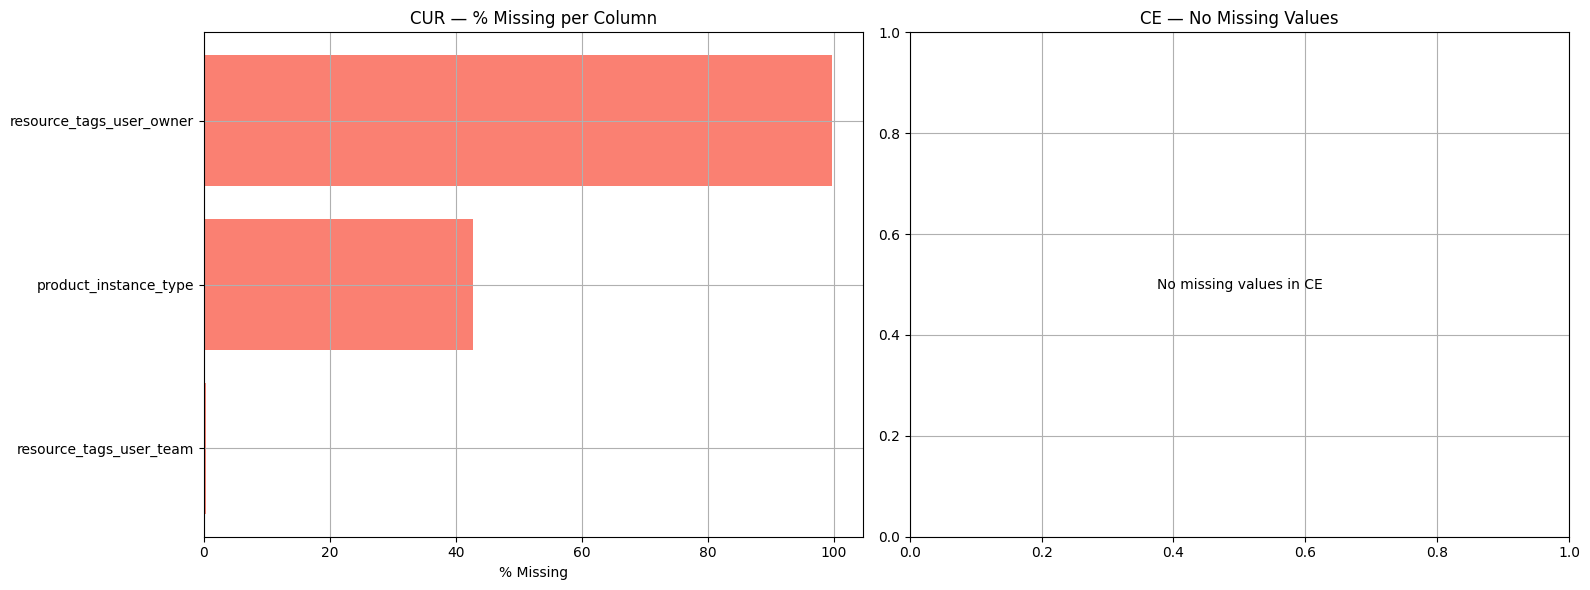

In [14]:
# Missing value heatmap for CUR (sample 500 rows for visibility)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CUR
miss_pct_cur = (cur.isnull().sum() / len(cur) * 100).sort_values(ascending=False)
miss_pct_cur = miss_pct_cur[miss_pct_cur > 0]
if len(miss_pct_cur):
    axes[0].barh(miss_pct_cur.index, miss_pct_cur.values, color='salmon')
    axes[0].set_xlabel('% Missing')
    axes[0].set_title('CUR — % Missing per Column')
    axes[0].invert_yaxis()
else:
    axes[0].text(0.5, 0.5, 'No missing values in CUR', ha='center', va='center', transform=axes[0].transAxes)
    axes[0].set_title('CUR — No Missing Values')

# CE
miss_pct_ce = (ce.isnull().sum() / len(ce) * 100).sort_values(ascending=False)
miss_pct_ce = miss_pct_ce[miss_pct_ce > 0]
if len(miss_pct_ce):
    axes[1].barh(miss_pct_ce.index, miss_pct_ce.values, color='steelblue')
    axes[1].set_xlabel('% Missing')
    axes[1].set_title('CE — % Missing per Column')
    axes[1].invert_yaxis()
else:
    axes[1].text(0.5, 0.5, 'No missing values in CE', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('CE — No Missing Values')

plt.tight_layout()
plt.show()

---
## Section 3 — Spend Overview: Total Bill Trend

In [15]:
# Section 9 — Parse label windows (ensure tz-naive Timestamps)
lbl['start_date'] = pd.to_datetime(lbl['start_date']).dt.tz_localize(None)
lbl['end_date']   = pd.to_datetime(lbl['end_date']).dt.tz_localize(None)

def get_label(aid):
    return lbl[lbl['anomaly_id'] == aid].iloc[0]

a2 = get_label('A2')
a6 = get_label('A6')
b2 = get_label('B2')

print('A2:', a2['resource_id'], '|', a2['anomaly_type'], '|', a2['start_date'].date(), '->', a2['end_date'].date())
print('A6:', a6['resource_id'], '|', a6['anomaly_type'], '|', a6['start_date'].date(), '->', a6['end_date'].date())
print('B2:', b2['resource_id'], '|', b2['label'],        '|', b2['start_date'].date(), '->', b2['end_date'].date())

A2: arn:aws:rds:us-east-1:acct:db:db-staging-orphan-01 | idle_resource | 2026-03-20 -> 2026-05-31
A6: log-group-debug-runaway | sudden_spike | 2026-04-28 -> 2026-05-04
B2: migration-egress-onetime | benign | 2026-03-28 -> 2026-03-30


In [16]:
# Monthly totals table
print('=== Monthly Spend Totals ===')
ce['month'] = ce['date'].dt.to_period('M')
monthly_ce = ce.groupby('month')['unblended_cost'].sum().reset_index()
monthly_ce.columns = ['Month', 'Total_Spend']
monthly_ce['MoM_Growth_%'] = monthly_ce['Total_Spend'].pct_change() * 100
monthly_ce['% of Total'] = monthly_ce['Total_Spend'] / monthly_ce['Total_Spend'].sum() * 100
monthly_ce['Total_Spend'] = monthly_ce['Total_Spend'].map('${:,.2f}'.format)
monthly_ce['MoM_Growth_%'] = monthly_ce['MoM_Growth_%'].map(lambda x: f'{x:.1f}%' if pd.notna(x) else 'baseline')
monthly_ce['% of Total'] = monthly_ce['% of Total'].map('{:.1f}%'.format)
display(monthly_ce)

=== Monthly Spend Totals ===


,Month,Total_Spend,MoM_Growth_%,% of Total
0,2026-03,"$186,806.12",baseline,31.5%
1,2026-04,"$196,080.37",5.0%,33.0%
2,2026-05,"$210,886.60",7.6%,35.5%


---
## Section 4 — Per-Account Spend Analysis

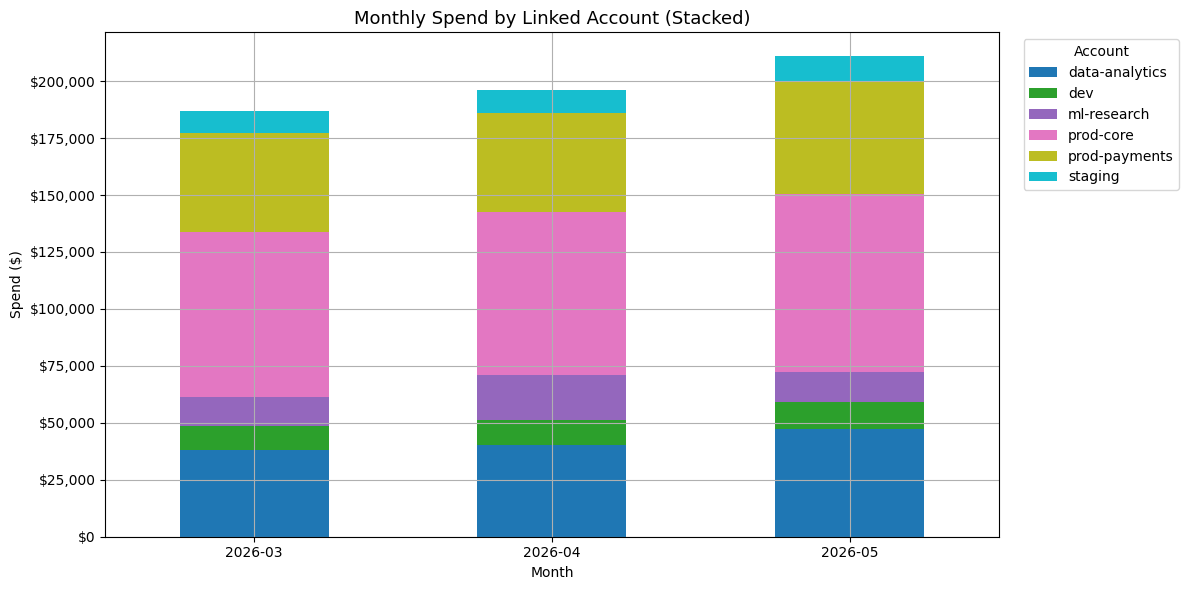

In [17]:
# Stacked bar: monthly spend per account
ce['month'] = ce['date'].dt.to_period('M')
acct_monthly = ce.groupby(['month', 'linked_account_name'])['unblended_cost'].sum().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
acct_monthly.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
ax.set_xlabel('Month')
ax.set_ylabel('Spend ($)')
ax.set_title('Monthly Spend by Linked Account (Stacked)', fontsize=13)
ax.legend(title='Account', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticklabels([str(p) for p in acct_monthly.index], rotation=0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

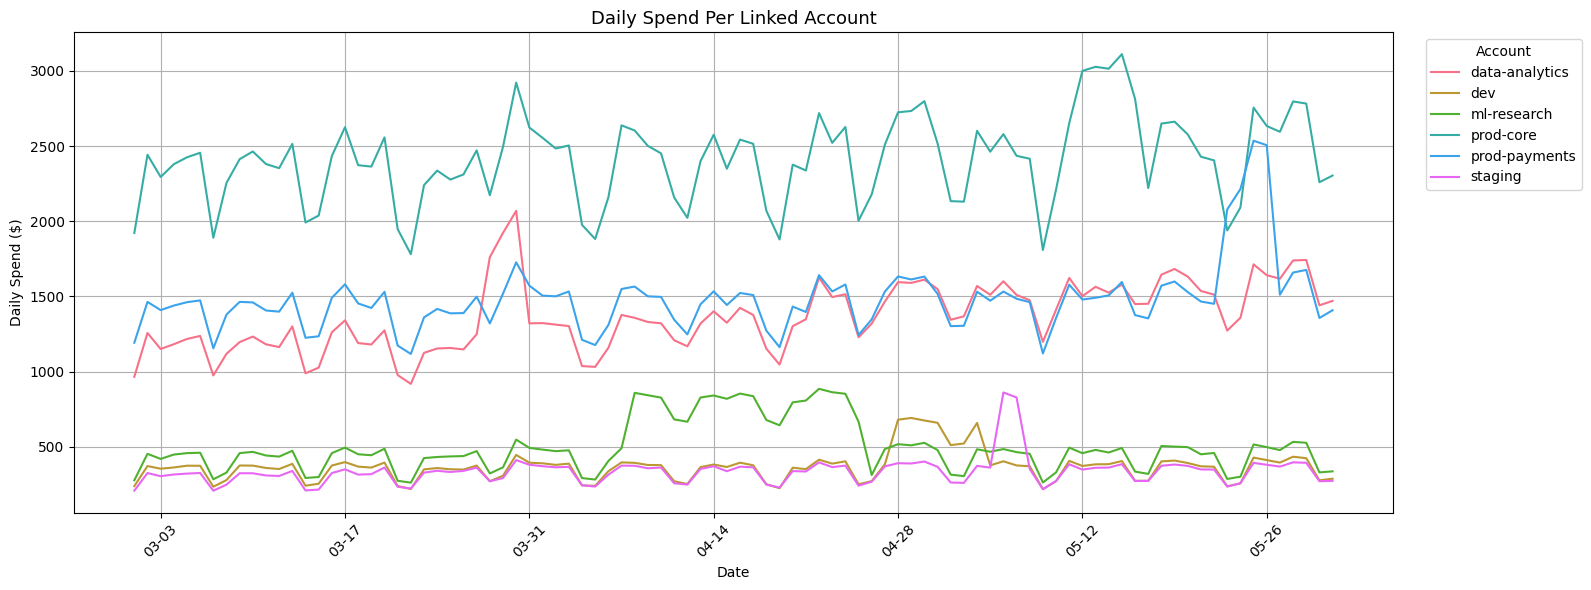

In [18]:
# Line chart: daily spend per account
daily_acct = ce.groupby(['date', 'linked_account_name'])['unblended_cost'].sum().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(16, 6))
for col in daily_acct.columns:
    ax.plot(daily_acct.index, daily_acct[col], label=col, linewidth=1.5)

ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.xticks(rotation=45)
ax.set_xlabel('Date')
ax.set_ylabel('Daily Spend ($)')
ax.set_title('Daily Spend Per Linked Account', fontsize=13)
ax.legend(title='Account', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [19]:
# % share of total spend per account
acct_total = ce.groupby('linked_account_name')['unblended_cost'].sum().sort_values(ascending=False)
acct_share = (acct_total / acct_total.sum() * 100).round(2)
acct_df = pd.DataFrame({'Total Spend ($)': acct_total.map('${:,.2f}'.format),
                         '% Share': acct_share.map('{:.2f}%'.format)})
print('=== Spend Share by Account ===')
display(acct_df)
print()
print(f'Dominant account: {acct_total.idxmax()} (${acct_total.max():,.2f})')

# Flag anomaly-prone accounts from labels
anomaly_accounts = lbl[lbl['label'] == 'anomaly']['linked_account_name'].unique()
benign_accounts  = lbl[lbl['label'] == 'benign']['linked_account_name'].unique()
print(f'Accounts with labeled anomalies: {list(anomaly_accounts)}')
print(f'Accounts with labeled benign events: {list(benign_accounts)}')

=== Spend Share by Account ===


,Total Spend ($),% Share
linked_account_name,,
prod-core,"$221,949.99",37.38%
prod-payments,"$136,092.65",22.92%
data-analytics,"$125,546.75",21.14%
ml-research,"$45,606.42",7.68%
dev,"$33,744.03",5.68%
staging,"$30,833.25",5.19%



Dominant account: prod-core ($221,949.99)
Accounts with labeled anomalies: ['staging', 'dev']
Accounts with labeled benign events: ['data-analytics']


---
## Section 5 — Per-Service Spend Analysis

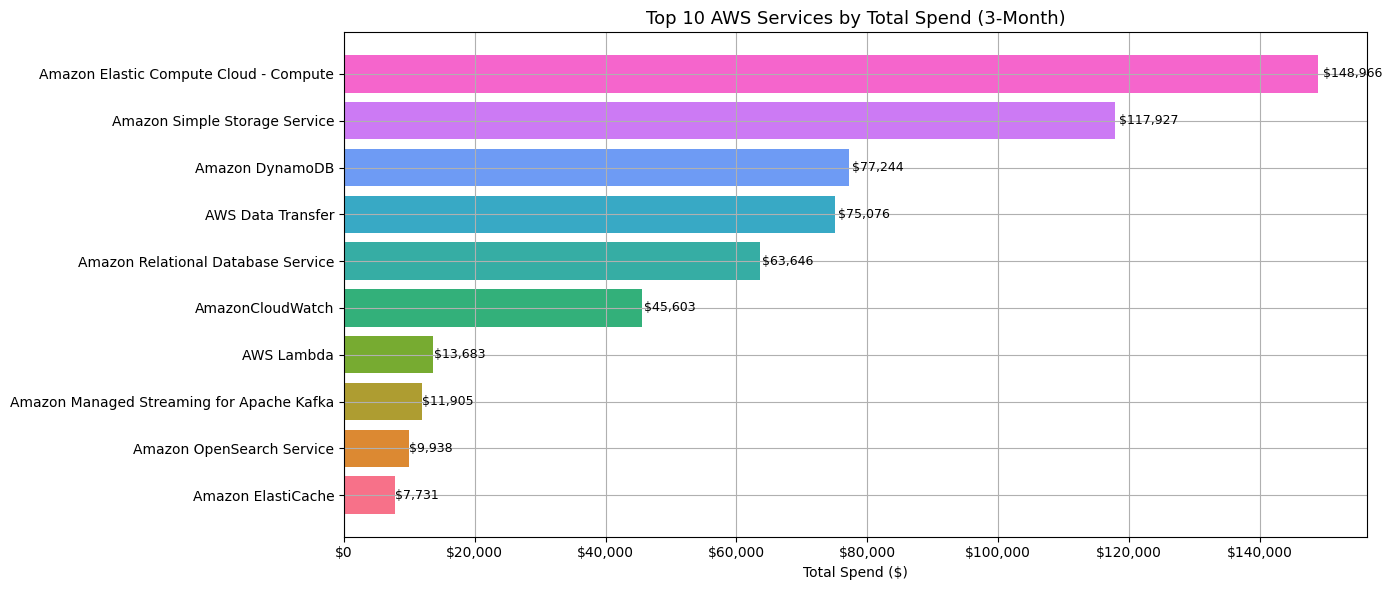


=== Top 10 Services ===
service
Amazon Elastic Compute Cloud - Compute       $148,965.52
Amazon Simple Storage Service                $117,927.20
Amazon DynamoDB                               $77,244.04
AWS Data Transfer                             $75,076.12
Amazon Relational Database Service            $63,645.75
AmazonCloudWatch                              $45,603.25
AWS Lambda                                    $13,683.02
Amazon Managed Streaming for Apache Kafka     $11,905.10
Amazon OpenSearch Service                      $9,938.46
Amazon ElastiCache                             $7,731.43


In [20]:
# Top 10 services by total spend (CE display names)
svc_total = ce.groupby('service')['unblended_cost'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
top10_svc = svc_total.head(10)
bars = ax.barh(top10_svc.index[::-1], top10_svc.values[::-1], color=sns.color_palette('husl', 10))
for i, (val) in enumerate(top10_svc.values[::-1]):
    ax.text(val * 1.005, i, f'${val:,.0f}', va='center', fontsize=9)
ax.set_xlabel('Total Spend ($)')
ax.set_title('Top 10 AWS Services by Total Spend (3-Month)', fontsize=13)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

print('\n=== Top 10 Services ===')
print(svc_total.head(10).map('${:,.2f}'.format).to_string())

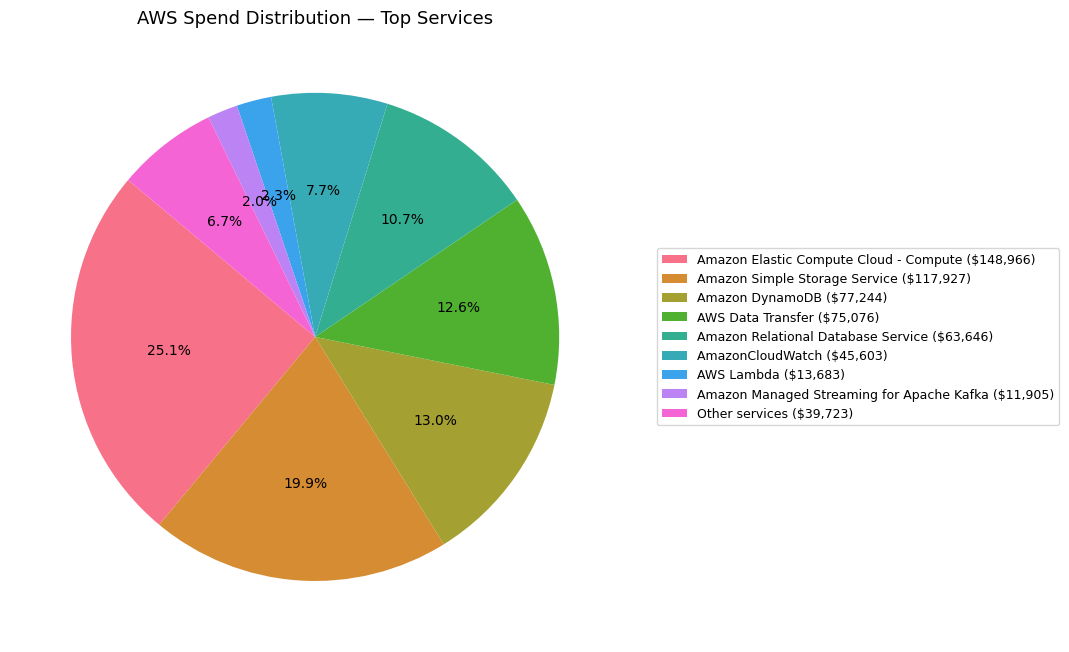

In [21]:
# Pie chart: top services spend distribution
fig, ax = plt.subplots(figsize=(10, 8))
top_n = svc_total.head(8)
others = svc_total.iloc[8:].sum()
pie_data = pd.concat([top_n, pd.Series({'Other services': others})])
wedges, texts, autotexts = ax.pie(
    pie_data.values,
    labels=None,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('husl', len(pie_data))
)
ax.legend(wedges, [f'{k} (${v:,.0f})' for k, v in pie_data.items()],
          loc='center left', bbox_to_anchor=(1.05, 0.5), fontsize=9)
ax.set_title('AWS Spend Distribution — Top Services', fontsize=13)
plt.tight_layout()
plt.show()

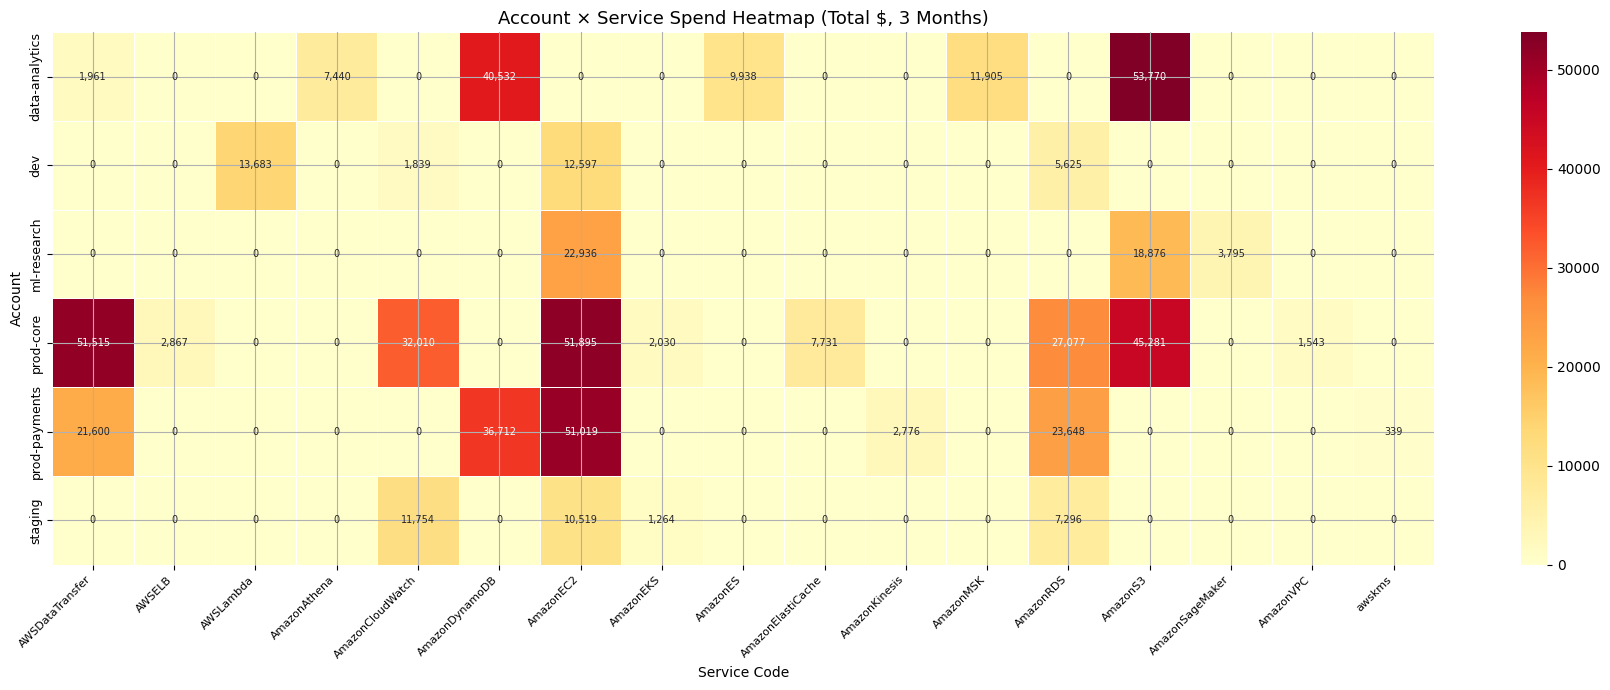

In [22]:
# Heatmap: account × service spend matrix
pivot_acct_svc = ce.pivot_table(
    index='linked_account_name',
    columns='service_code',
    values='unblended_cost',
    aggfunc='sum',
    fill_value=0
)

fig, ax = plt.subplots(figsize=(18, 7))
sns.heatmap(
    pivot_acct_svc,
    annot=True,
    fmt=',.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 7}
)
ax.set_title('Account × Service Spend Heatmap (Total $, 3 Months)', fontsize=13)
ax.set_xlabel('Service Code')
ax.set_ylabel('Account')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

---
## Section 6 — CUR Resource-Level Deep Dive

In [23]:
# Top 20 most expensive resources
res_total = (
    cur.groupby(['line_item_resource_id', 'line_item_product_code', 'line_item_usage_account_name'])
       ['line_item_unblended_cost'].sum()
       .reset_index()
       .sort_values('line_item_unblended_cost', ascending=False)
       .head(20)
)
res_total.columns = ['resource_id', 'service', 'account', 'total_cost_usd']
res_total['total_cost_usd'] = res_total['total_cost_usd'].round(2)
print('=== Top 20 Most Expensive Resources ===')
display(res_total.reset_index(drop=True))

=== Top 20 Most Expensive Resources ===


,resource_id,service,account,total_cost_usd
0,bucket-1220,AmazonS3,data-analytics,53770.27
1,res-awsdatatransfer-1053,AWSDataTransfer,prod-core,48879.75
2,bucket-1054,AmazonS3,prod-core,45281.14
3,res-amazondynamodb-1067,AmazonDynamoDB,prod-payments,36711.66
4,res-amazoncloudwatch-1046,AmazonCloudWatch,prod-core,32010.35
5,res-amazondynamodb-1230,AmazonDynamoDB,data-analytics,27225.38
6,res-awsdatatransfer-1146,AWSDataTransfer,prod-payments,21599.97
7,bucket-1250,AmazonS3,ml-research,18875.90
8,res-awslambda-1214,AWSLambda,dev,13683.02
9,i-0untaggedfleet01,AmazonEC2,prod-payments,13606.23


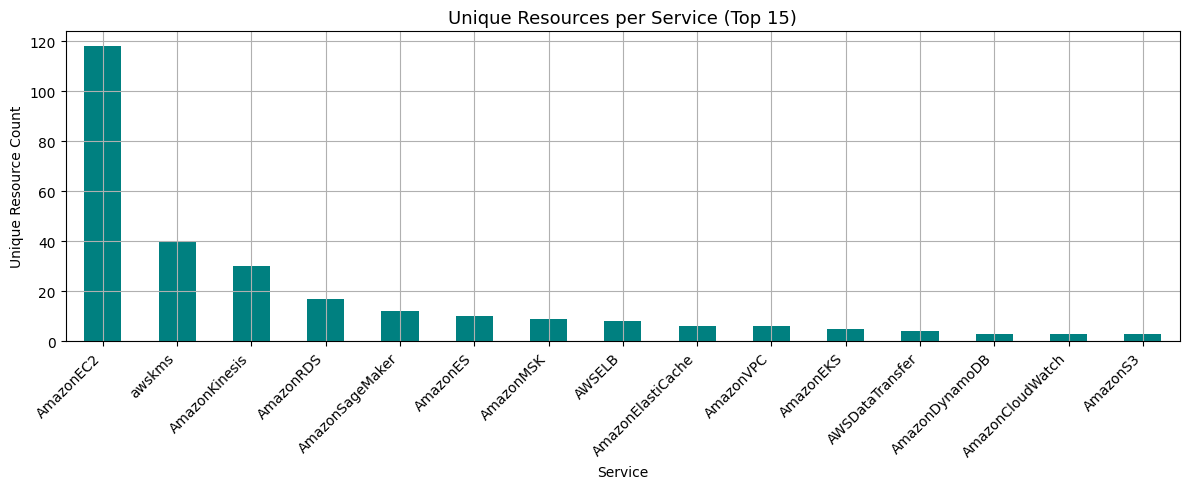


=== Resource Count per Service ===
line_item_product_code
AmazonEC2            118
awskms                40
AmazonKinesis         30
AmazonRDS             17
AmazonSageMaker       12
AmazonES              10
AmazonMSK              9
AWSELB                 8
AmazonElastiCache      6
AmazonVPC              6
AmazonEKS              5
AWSDataTransfer        4
AmazonDynamoDB         3
AmazonCloudWatch       3
AmazonS3               3
AmazonAthena           1
AWSLambda              1


In [24]:
# Resource count per service
res_per_svc = (
    cur.groupby('line_item_product_code')['line_item_resource_id']
       .nunique()
       .sort_values(ascending=False)
)
fig, ax = plt.subplots(figsize=(12, 5))
res_per_svc.head(15).plot(kind='bar', ax=ax, color='teal')
ax.set_xlabel('Service')
ax.set_ylabel('Unique Resource Count')
ax.set_title('Unique Resources per Service (Top 15)', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\n=== Resource Count per Service ===')
print(res_per_svc.to_string())

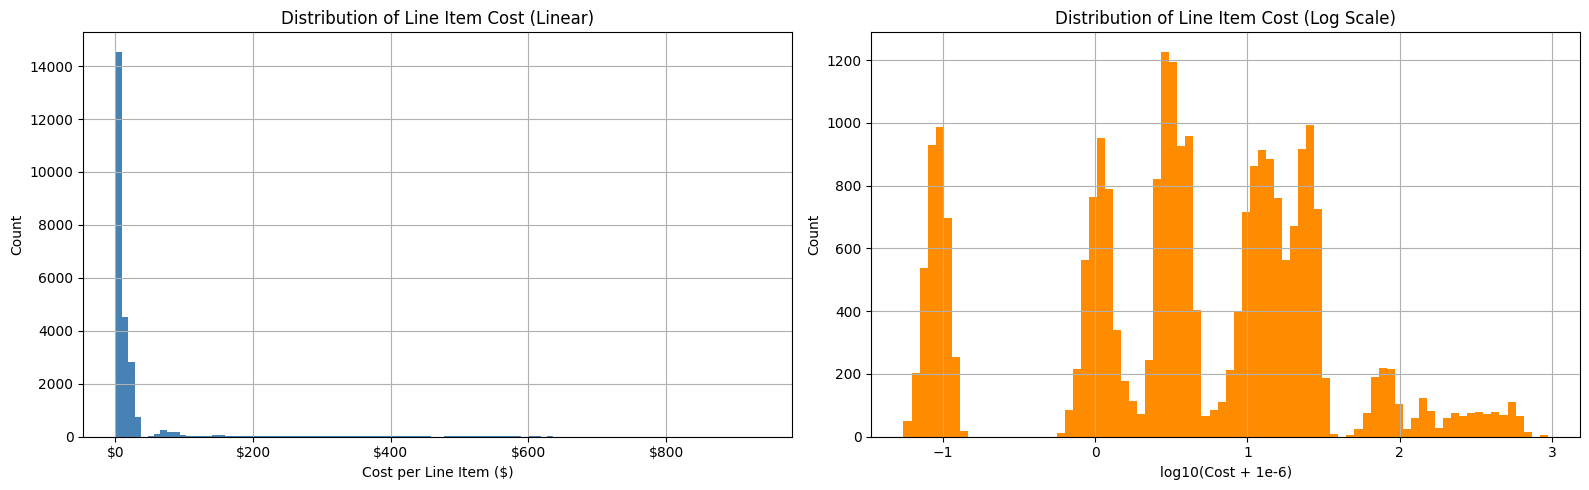

Cost stats (positive only):
count    24533.000000
mean        24.203047
std         73.895738
min          0.055300
25%          1.139600
50%          3.962000
75%         16.465000
max        935.739500


In [25]:
# Distribution of line_item_unblended_cost (log scale)
costs = cur['line_item_unblended_cost']
costs_pos = costs[costs > 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# Linear
axes[0].hist(costs_pos, bins=100, color='steelblue', edgecolor='none')
axes[0].set_xlabel('Cost per Line Item ($)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Line Item Cost (Linear)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Log scale on x-axis
axes[1].hist(np.log10(costs_pos + 1e-6), bins=80, color='darkorange', edgecolor='none')
axes[1].set_xlabel('log10(Cost + 1e-6)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Line Item Cost (Log Scale)')

plt.tight_layout()
plt.show()

print(f'Cost stats (positive only):')
print(costs_pos.describe().to_string())

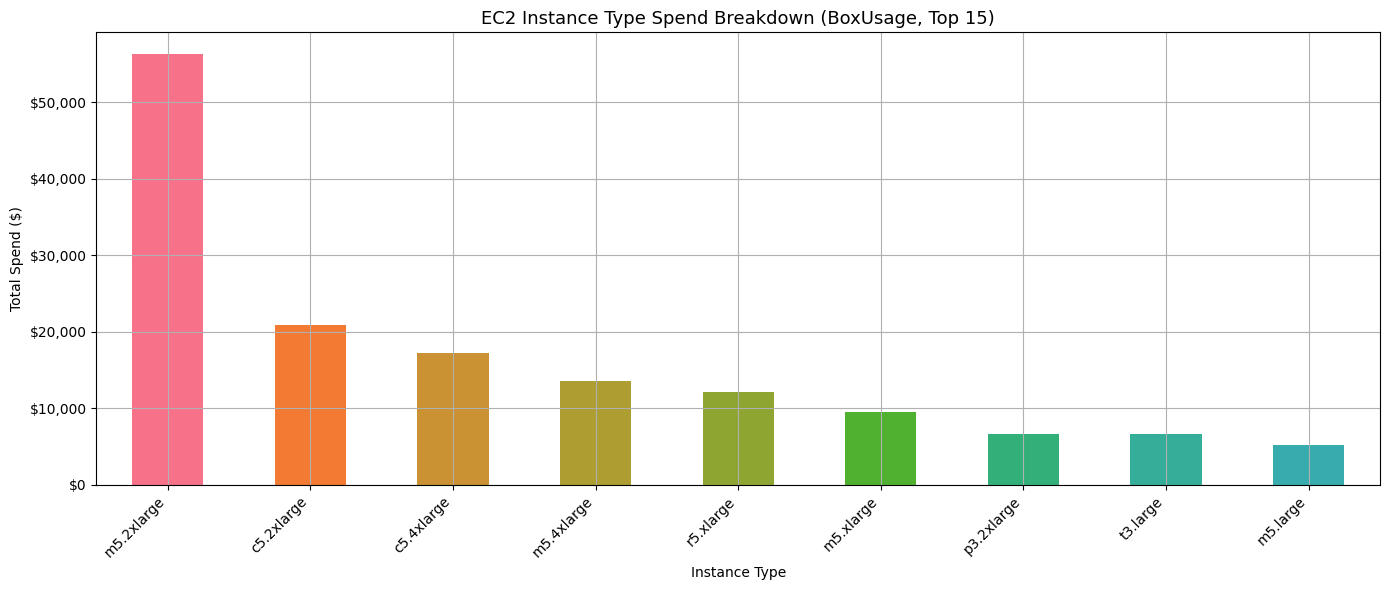


=== Top EC2 Instance Types by Spend ===
instance_type
m5.2xlarge    $56,297.18
c5.2xlarge    $20,830.64
c5.4xlarge    $17,283.48
m5.4xlarge    $13,606.23
r5.xlarge     $12,179.68
m5.xlarge      $9,546.55
p3.2xlarge     $6,624.98
t3.large       $6,598.00
m5.large       $5,169.51


In [26]:
# EC2 instance type breakdown
ec2 = cur[cur['line_item_product_code'] == 'AmazonEC2'].copy()
# BoxUsage types carry instance type in the usage_type column
box = ec2[ec2['line_item_usage_type'].str.contains('BoxUsage', na=False)]
if len(box):
    box['instance_type'] = box['line_item_usage_type'].str.extract(r'BoxUsage:(.+)')
    it_spend = box.groupby('instance_type')['line_item_unblended_cost'].sum().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(14, 6))
    it_spend.head(15).plot(kind='bar', ax=ax, color=sns.color_palette('husl', 15))
    ax.set_xlabel('Instance Type')
    ax.set_ylabel('Total Spend ($)')
    ax.set_title('EC2 Instance Type Spend Breakdown (BoxUsage, Top 15)', fontsize=13)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    print('\n=== Top EC2 Instance Types by Spend ===')
    print(it_spend.head(15).map('${:,.2f}'.format).to_string())
else:
    print('No BoxUsage line items found in EC2.')

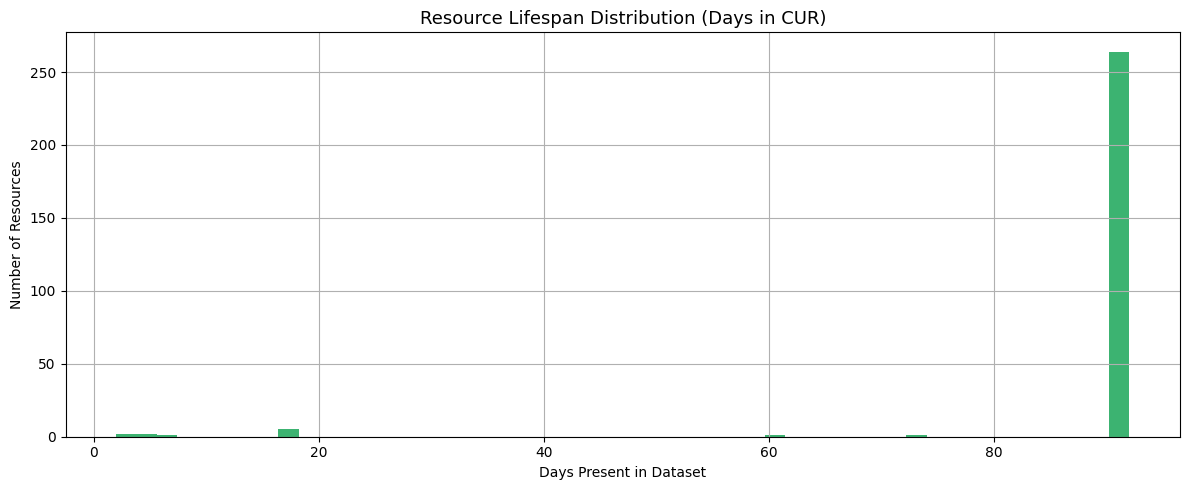

Resources by lifespan:
  1 day only      : 0
  2-6 days        : 4
  7-30 days       : 6
  31-60 days      : 0
  61-92 days      : 266
  Total resources : 276


In [27]:
# Resource lifespan: how many unique days each resource appears
res_days = (
    cur.groupby('line_item_resource_id')['line_item_usage_start_date']
       .nunique()
       .rename('days_present')
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(res_days.values, bins=50, color='mediumseagreen', edgecolor='none')
ax.set_xlabel('Days Present in Dataset')
ax.set_ylabel('Number of Resources')
ax.set_title('Resource Lifespan Distribution (Days in CUR)', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Resources by lifespan:')
print(f'  1 day only      : {(res_days == 1).sum()}')
print(f'  2-6 days        : {((res_days >= 2) & (res_days <= 6)).sum()}')
print(f'  7-30 days       : {((res_days >= 7) & (res_days <= 30)).sum()}')
print(f'  31-60 days      : {((res_days >= 31) & (res_days <= 60)).sum()}')
print(f'  61-92 days      : {((res_days >= 61)).sum()}')
print(f'  Total resources : {len(res_days)}')

---
## Section 7 — Tag Coverage Analysis (Untagged Spend)

In [28]:
# Tag columns to analyze
TAG_COLS = [
    'resource_tags_user_team',
    'resource_tags_user_environment',
    'resource_tags_user_cost_center',
    'resource_tags_user_owner',
]

# Count missing vs filled for each tag
tag_stats = []
for col in TAG_COLS:
    if col in cur.columns:
        filled = cur[col].notna() & (cur[col].str.strip() != '')
        missing = ~filled
        spend_tagged   = cur.loc[filled, 'line_item_unblended_cost'].sum()
        spend_untagged = cur.loc[missing, 'line_item_unblended_cost'].sum()
        tag_stats.append({
            'tag': col.replace('resource_tags_user_', ''),
            'rows_tagged': filled.sum(),
            'rows_untagged': missing.sum(),
            'pct_untagged': missing.sum() / len(cur) * 100,
            'spend_tagged': spend_tagged,
            'spend_untagged': spend_untagged,
            'pct_spend_untagged': spend_untagged / cur['line_item_unblended_cost'].sum() * 100
        })

tag_df = pd.DataFrame(tag_stats)
tag_df['spend_tagged']       = tag_df['spend_tagged'].map('${:,.2f}'.format)
tag_df['spend_untagged']     = tag_df['spend_untagged'].map('${:,.2f}'.format)
tag_df['pct_untagged']       = tag_df['pct_untagged'].map('{:.1f}%'.format)
tag_df['pct_spend_untagged'] = tag_df['pct_spend_untagged'].map('{:.1f}%'.format)
print('=== Tag Coverage Summary ===')
display(tag_df)

=== Tag Coverage Summary ===


,tag,rows_tagged,rows_untagged,pct_untagged,spend_tagged,spend_untagged,pct_spend_untagged
0,team,24441,92,0.4%,"$580,167.11","$13,606.23",2.3%
1,environment,24533,0,0.0%,"$593,773.34",$0.00,0.0%
2,cost_center,24533,0,0.0%,"$593,773.34",$0.00,0.0%
3,owner,90,24443,99.6%,"$6,624.98","$587,148.36",98.9%


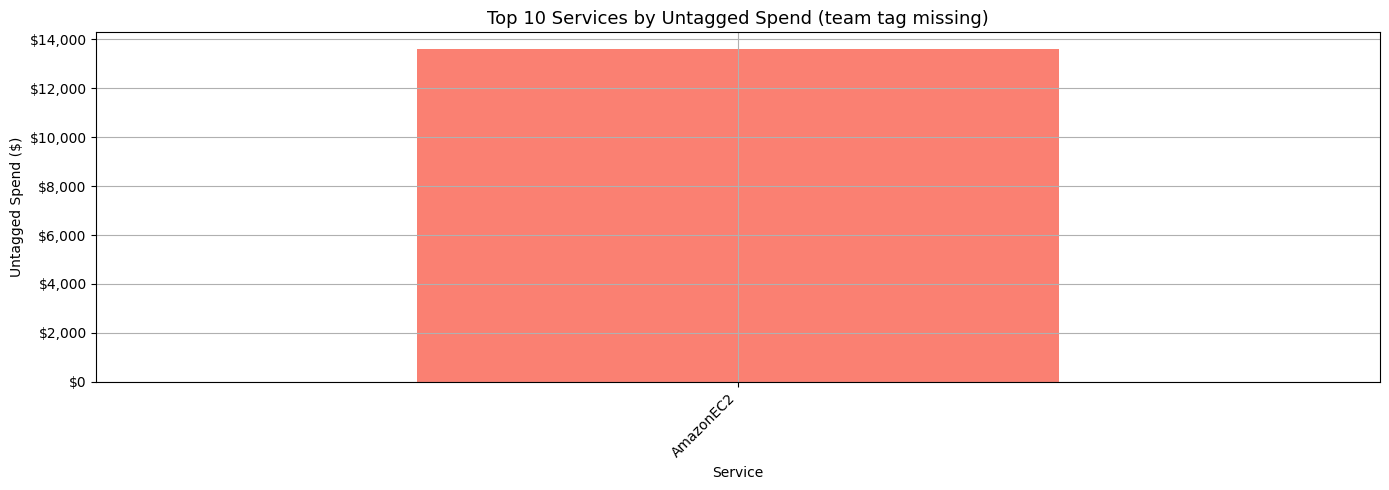

In [29]:
# Bar chart: untagged spend by service (top 10) — using team tag as primary
team_col = 'resource_tags_user_team'
if team_col in cur.columns:
    untagged_mask = cur[team_col].isna() | (cur[team_col].str.strip() == '')
    untagged = cur[untagged_mask]
    
    untagged_by_svc = (
        untagged.groupby('line_item_product_code')['line_item_unblended_cost']
                .sum().sort_values(ascending=False).head(10)
    )
    
    fig, ax = plt.subplots(figsize=(14, 5))
    untagged_by_svc.plot(kind='bar', ax=ax, color='salmon')
    ax.set_xlabel('Service')
    ax.set_ylabel('Untagged Spend ($)')
    ax.set_title('Top 10 Services by Untagged Spend (team tag missing)', fontsize=13)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

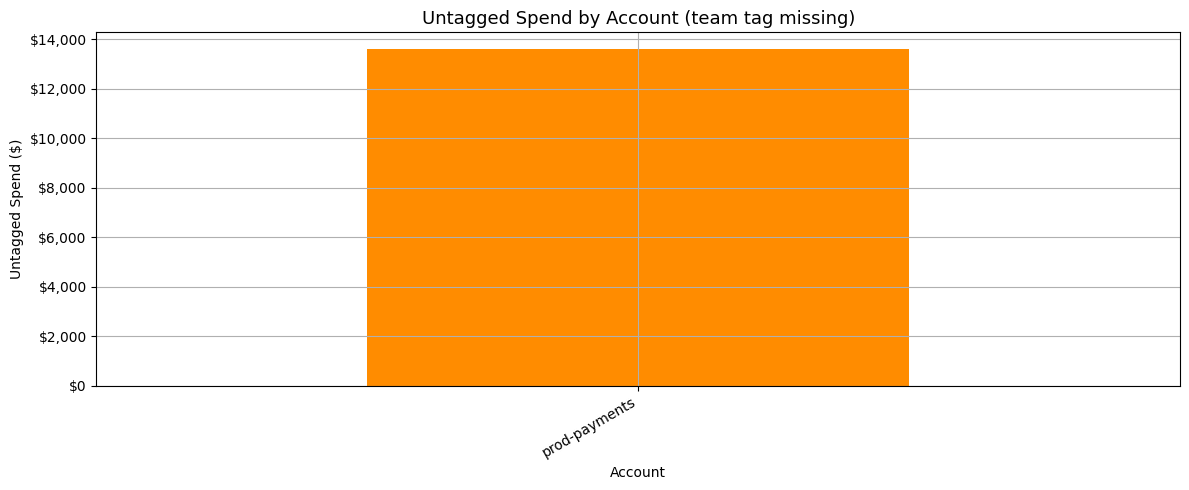

Total spend         : $593,773.34
Untagged spend      : $13,606.23
% of bill untagged  : 2.29%

→ This directly maps to the untagged_spend anomaly type.
→ Resources with high untagged $ and no team attribution = anomaly candidates.


In [30]:
# Bar chart: untagged spend by account
if team_col in cur.columns:
    untagged_by_acct = (
        untagged.groupby('line_item_usage_account_name')['line_item_unblended_cost']
                .sum().sort_values(ascending=False)
    )
    
    fig, ax = plt.subplots(figsize=(12, 5))
    untagged_by_acct.plot(kind='bar', ax=ax, color='darkorange')
    ax.set_xlabel('Account')
    ax.set_ylabel('Untagged Spend ($)')
    ax.set_title('Untagged Spend by Account (team tag missing)', fontsize=13)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()
    
    total_spend = cur['line_item_unblended_cost'].sum()
    total_untagged_spend = untagged['line_item_unblended_cost'].sum()
    pct_untagged = total_untagged_spend / total_spend * 100
    print(f'Total spend         : ${total_spend:,.2f}')
    print(f'Untagged spend      : ${total_untagged_spend:,.2f}')
    print(f'% of bill untagged  : {pct_untagged:.2f}%')
    print()
    print('→ This directly maps to the untagged_spend anomaly type.')
    print('→ Resources with high untagged $ and no team attribution = anomaly candidates.')

---
## Section 8 — Temporal Patterns & Seasonality

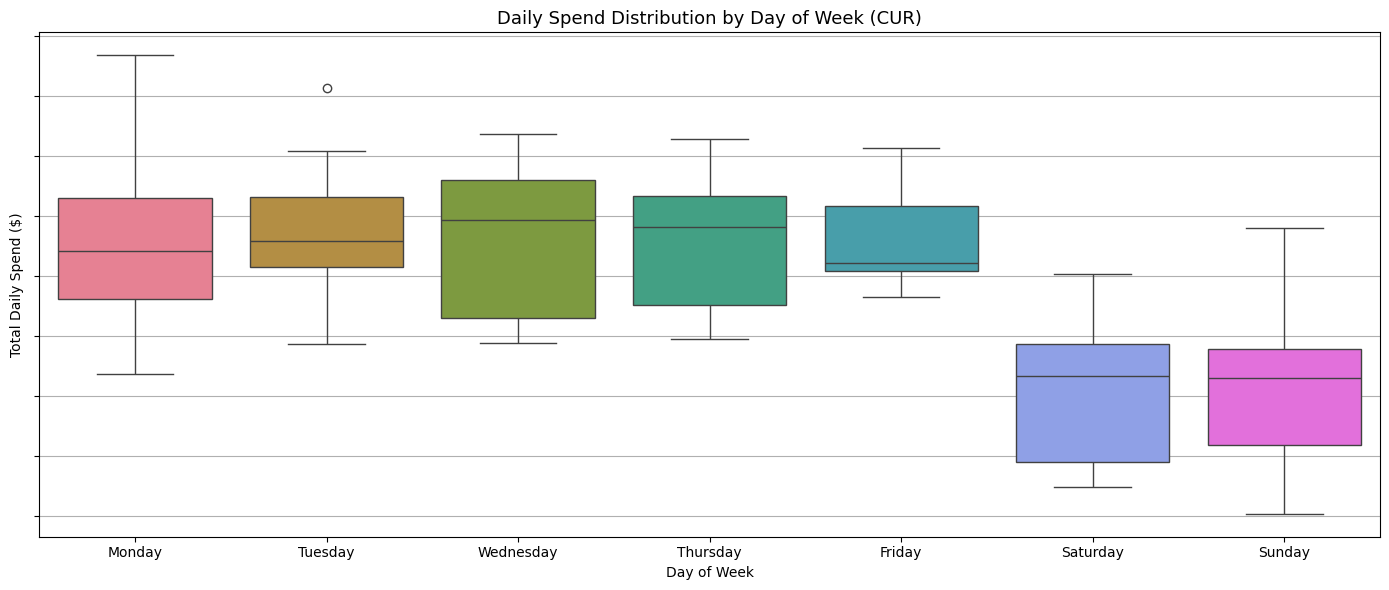

Mean weekday spend    : 
Mean weekend spend    : 
Weekend/Weekday ratio : 0.818  (expected <1 for healthy infra)


In [31]:
# Section 8 — Weekday vs weekend spend distribution
cur['day_of_week'] = cur['line_item_usage_start_date'].dt.day_name()
cur['dow_num']     = cur['line_item_usage_start_date'].dt.dayofweek  # 0=Monday
cur['is_weekend']  = cur['dow_num'] >= 5

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Normalize datetime to date only, then group — avoids MultiIndex from mixed types
cur['_date_only'] = cur['line_item_usage_start_date'].dt.normalize()
daily_by_day = (
    cur.groupby(['_date_only', 'day_of_week'])
       ['line_item_unblended_cost'].sum()
       .reset_index()
)
daily_by_day.columns = ['date', 'day_of_week', 'daily_cost']

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=daily_by_day, x='day_of_week', y='daily_cost',
            order=day_order, palette='husl', ax=ax)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Total Daily Spend ($)')
ax.set_title('Daily Spend Distribution by Day of Week (CUR)', fontsize=13)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f''))
plt.tight_layout()
plt.show()

wkday_mean = daily_by_day[daily_by_day['day_of_week'].isin(['Monday','Tuesday','Wednesday','Thursday','Friday'])]['daily_cost'].mean()
wkend_mean = daily_by_day[daily_by_day['day_of_week'].isin(['Saturday','Sunday'])]['daily_cost'].mean()
print(f'Mean weekday spend    : ')
print(f'Mean weekend spend    : ')
print(f'Weekend/Weekday ratio : {wkend_mean/wkday_mean:.3f}  (expected <1 for healthy infra)')

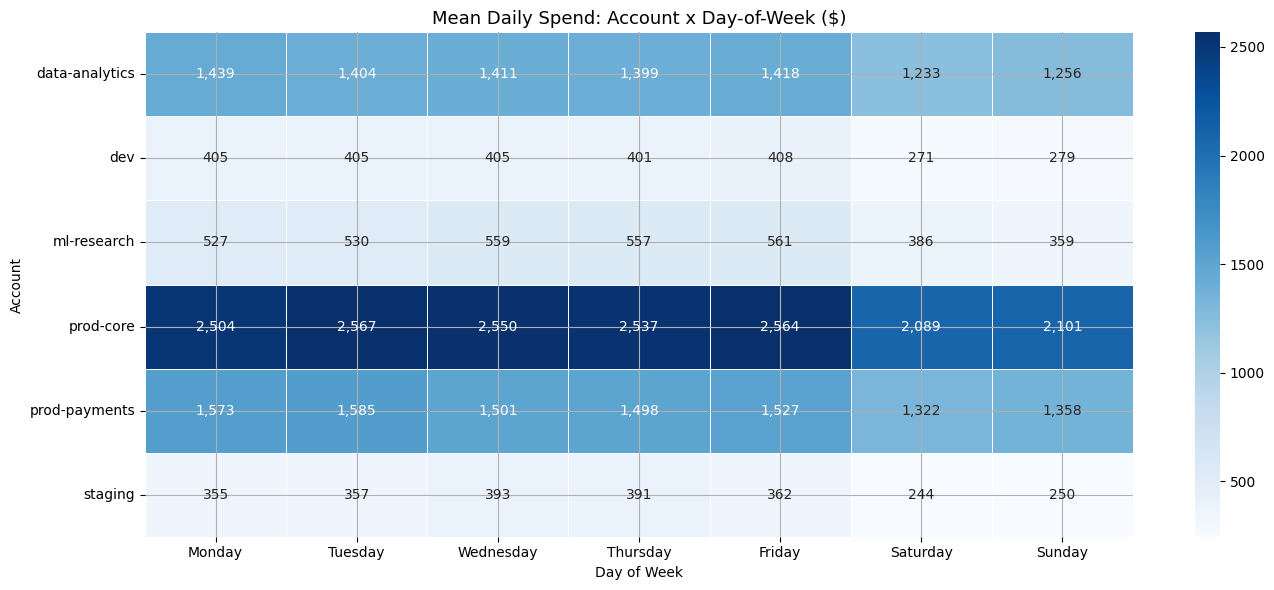

In [32]:
# Heatmap: day-of-week x account mean daily spend
daily_dow_acct = (
    cur.groupby(['_date_only', 'day_of_week', 'line_item_usage_account_name'])
       ['line_item_unblended_cost'].sum()
       .reset_index()
)
daily_dow_acct.columns = ['date', 'day_of_week', 'account', 'daily_cost']

pivot_dow = daily_dow_acct.pivot_table(
    index='account', columns='day_of_week', values='daily_cost', aggfunc='mean'
)
pivot_dow = pivot_dow[[d for d in day_order if d in pivot_dow.columns]]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_dow, annot=True, fmt=',.0f', cmap='Blues', linewidths=0.5, ax=ax)
ax.set_title('Mean Daily Spend: Account x Day-of-Week (\$)', fontsize=13)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Account')
plt.tight_layout()
plt.show()

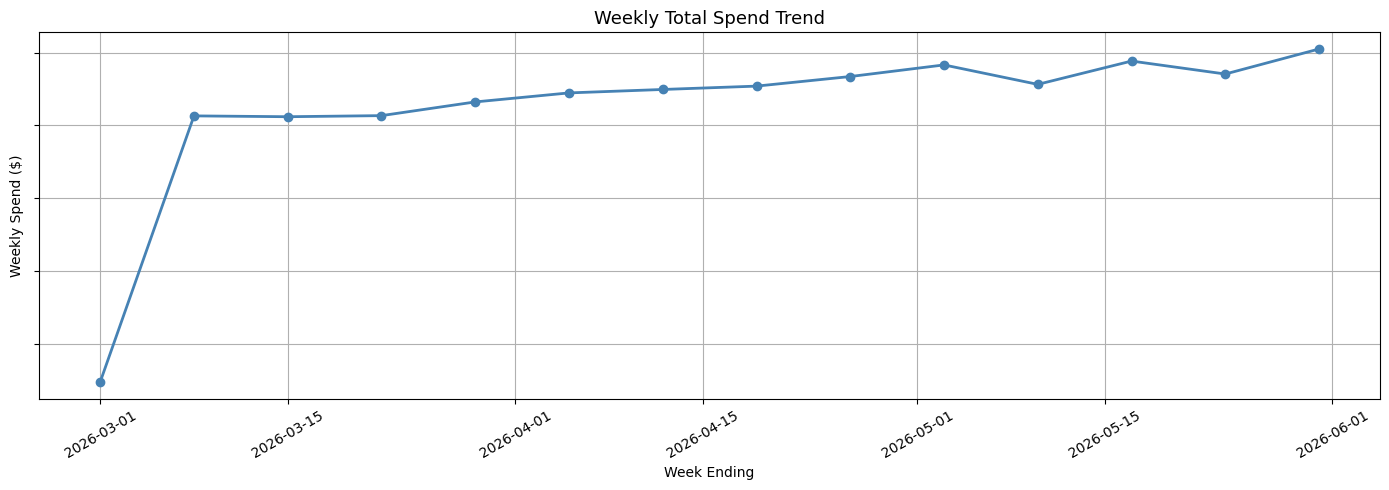

In [33]:
# Weekly average spend trend
ce_weekly = (
    ce.set_index('date')
      .resample('W')['unblended_cost']
      .sum()
      .reset_index()
)
ce_weekly.columns = ['week_ending', 'weekly_spend']

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ce_weekly['week_ending'], ce_weekly['weekly_spend'], marker='o', color='steelblue', linewidth=2)
ax.set_xlabel('Week Ending')
ax.set_ylabel('Weekly Spend (\$)')
ax.set_title('Weekly Total Spend Trend', fontsize=13)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f''))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

=== Month-over-Month Growth % per Account ===


linked_account_name,data-analytics,dev,ml-research,prod-core,prod-payments,staging
month,,,,,,
2026-03,NaN,NaN,NaN,NaN,NaN,NaN
2026-04,4.78,7.51,52.38,-0.49,-0.53,5.70
2026-05,17.88,6.03,-31.77,8.67,12.92,13.25


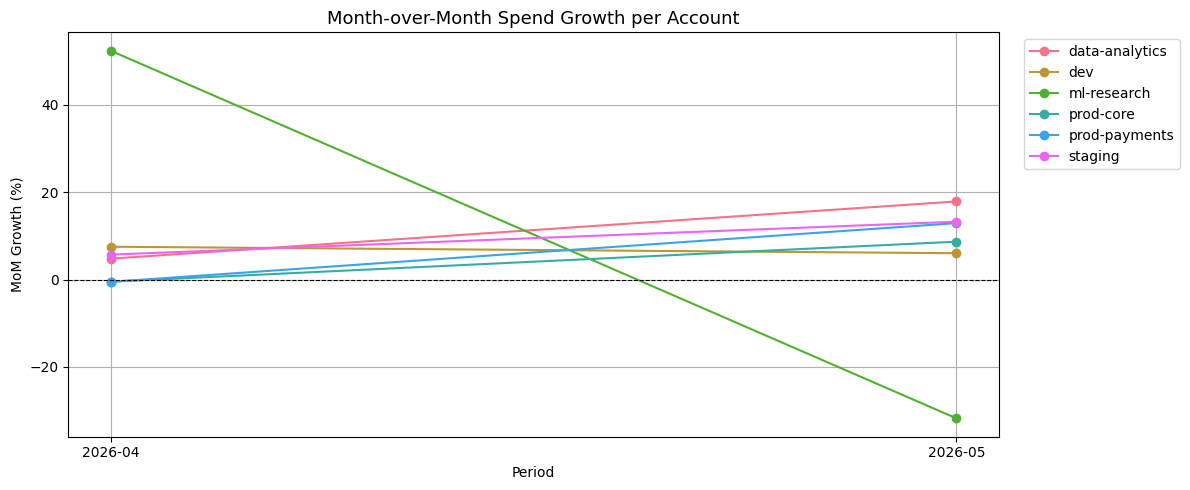

In [34]:
# Month-over-month growth rate per account
# Avoid re-assigning ce['month'] if already exists — use a fresh groupby key
ce_copy = ce.copy()
ce_copy['month'] = ce_copy['date'].dt.to_period('M')
mom_acct = ce_copy.groupby(['month', 'linked_account_name'])['unblended_cost'].sum().unstack()
mom_pct  = mom_acct.pct_change() * 100

print('=== Month-over-Month Growth % per Account ===')
display(mom_pct.round(2))

fig, ax = plt.subplots(figsize=(12, 5))
for col in mom_pct.columns:
    ax.plot(mom_pct.index.astype(str), mom_pct[col], marker='o', label=col)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Period')
ax.set_ylabel('MoM Growth (%)')
ax.set_title('Month-over-Month Spend Growth per Account', fontsize=13)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [35]:
# Resources active on weekends (runaway_usage preview)
res_weekend = (
    cur[cur['is_weekend']]
       .groupby('line_item_resource_id')['line_item_unblended_cost']
       .agg(weekend_spend='sum', weekend_line_items='count')
       .sort_values('weekend_spend', ascending=False)
)

res_total_days = (
    cur.groupby('line_item_resource_id')['line_item_usage_start_date']
       .nunique()
       .rename('total_days')
)
res_weekend = res_weekend.join(res_total_days)

weekend_runaway = res_weekend[
    (res_weekend['weekend_spend'] > 50) &
    (res_weekend['total_days'] >= 7)
]

print(f'Resources active weekends with >\ weekend spend AND 7+ total days: {len(weekend_runaway)}')
print(f'Total weekend spend for these candidates: ')
print()
print('Top 10 weekend-active candidates (runaway_usage signal):')
display(weekend_runaway.head(10))

Resources active weekends with >\ weekend spend AND 7+ total days: 154
Total weekend spend for these candidates: 

Top 10 weekend-active candidates (runaway_usage signal):


,weekend_spend,weekend_line_items,total_days
line_item_resource_id,,,
bucket-1220,13761.9833,27,92
res-awsdatatransfer-1053,12473.4713,27,92
bucket-1054,11532.1111,27,92
res-amazondynamodb-1067,9387.8267,27,92
res-amazoncloudwatch-1046,8239.6273,27,92
res-amazondynamodb-1230,6949.5063,27,92
res-awsdatatransfer-1146,5532.6900,27,92
bucket-1250,4838.6991,27,92
ddb-table-events-prod,4083.9038,18,61


---
## Section 9 — Anomaly Signal Analysis (Known Labels)

In [36]:
# Parse label windows
# lbl dates are already tz-naive from the load cell; re-cast defensively
lbl['start_date'] = pd.to_datetime(lbl['start_date']).dt.tz_localize(None)
lbl['end_date']   = pd.to_datetime(lbl['end_date']).dt.tz_localize(None)

def get_label(aid):
    return lbl[lbl['anomaly_id'] == aid].iloc[0]

a2 = get_label('A2')
a6 = get_label('A6')
b2 = get_label('B2')

print('A2:', a2['resource_id'], '|', a2['anomaly_type'], '|', a2['start_date'].date(), '->', a2['end_date'].date())
print('A6:', a6['resource_id'], '|', a6['anomaly_type'], '|', a6['start_date'].date(), '->', a6['end_date'].date())
print('B2:', b2['resource_id'], '|', b2['label'],       '|', b2['start_date'].date(), '->', b2['end_date'].date())

A2: arn:aws:rds:us-east-1:acct:db:db-staging-orphan-01 | idle_resource | 2026-03-20 -> 2026-05-31
A6: log-group-debug-runaway | sudden_spike | 2026-04-28 -> 2026-05-04
B2: migration-egress-onetime | benign | 2026-03-28 -> 2026-03-30


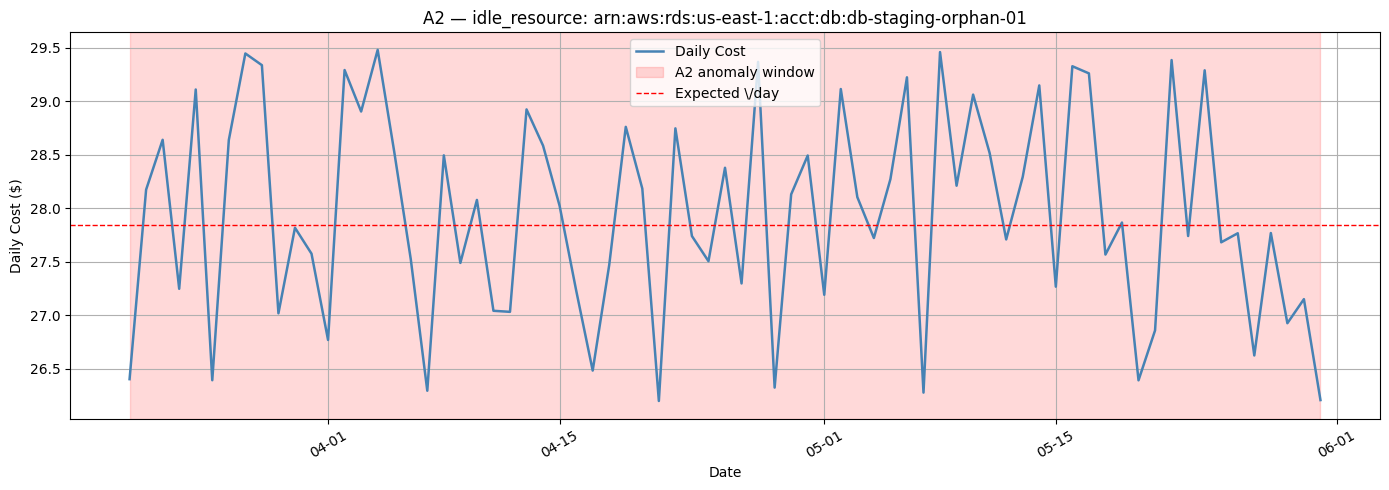

A2 resource rows found: 73
  No baseline rows before window.
  During anomaly window mean    : \/day


In [37]:
# A2 — idle_resource: staging RDS daily cost over time
a2_rid = a2['resource_id']
a2_data = (
    cur[cur['line_item_resource_id'] == a2_rid]
       .groupby(cur['line_item_usage_start_date'].dt.normalize())
       ['line_item_unblended_cost'].sum()
       .reset_index()
)
a2_data.columns = ['date', 'daily_cost']

if len(a2_data) == 0:
    matches = cur[cur['line_item_resource_id'].str.contains('db-staging-orphan', na=False)]
    if len(matches):
        a2_data = matches.groupby(matches['line_item_usage_start_date'].dt.normalize())['line_item_unblended_cost'].sum().reset_index()
        a2_data.columns = ['date', 'daily_cost']
        print(f'Using substring match for A2 resource.')

# Ensure date column is tz-naive datetime for comparison
a2_data['date'] = pd.to_datetime(a2_data['date']).dt.tz_localize(None)

sd_a2 = pd.Timestamp(a2['start_date']).tz_localize(None) if pd.Timestamp(a2['start_date']).tzinfo is not None else pd.Timestamp(a2['start_date'])
ed_a2 = pd.Timestamp(a2['end_date']).tz_localize(None)   if pd.Timestamp(a2['end_date']).tzinfo   is not None else pd.Timestamp(a2['end_date'])

fig, ax = plt.subplots(figsize=(14, 5))
if len(a2_data):
    ax.plot(a2_data['date'], a2_data['daily_cost'], color='steelblue', linewidth=1.8, label='Daily Cost')
ax.axvspan(sd_a2, ed_a2, color='red', alpha=0.15, label='A2 anomaly window')
ax.axhline(a2['approx_daily_cost'], color='red', linestyle='--', linewidth=1,
           label=f'Expected \/day')
ax.set_title(f'A2 — idle_resource: {str(a2_rid)[:70]}', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Daily Cost (\$)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(f'A2 resource rows found: {len(a2_data)}')
if len(a2_data):
    baseline = a2_data[a2_data['date'] < sd_a2]['daily_cost'].mean()
    during   = a2_data[(a2_data['date'] >= sd_a2) & (a2_data['date'] <= ed_a2)]['daily_cost'].mean()
    print(f'  Baseline mean (before window) : \/day' if baseline == baseline else '  No baseline rows before window.')
    print(f'  During anomaly window mean    : \/day'  if during   == during   else '  No rows in anomaly window.')

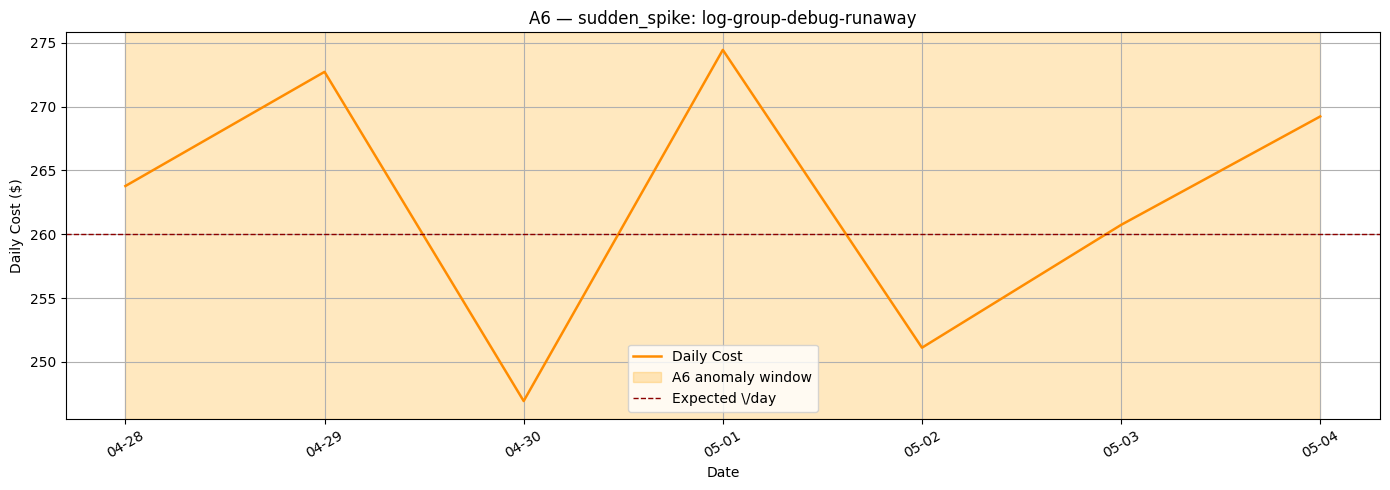

A6 resource rows found: 7
  No baseline rows.
  During spike window mean      : \/day


In [38]:
# A6 — sudden_spike: dev CloudWatch daily cost over time
a6_rid = a6['resource_id']
a6_data = (
    cur[cur['line_item_resource_id'] == a6_rid]
       .groupby(cur['line_item_usage_start_date'].dt.normalize())
       ['line_item_unblended_cost'].sum()
       .reset_index()
)
a6_data.columns = ['date', 'daily_cost']

if len(a6_data) == 0:
    matches = cur[cur['line_item_resource_id'].str.contains('debug-runaway', na=False)]
    if len(matches):
        a6_data = matches.groupby(matches['line_item_usage_start_date'].dt.normalize())['line_item_unblended_cost'].sum().reset_index()
        a6_data.columns = ['date', 'daily_cost']
        print('Using substring match for A6 resource.')

a6_data['date'] = pd.to_datetime(a6_data['date']).dt.tz_localize(None)

sd_a6 = pd.Timestamp(a6['start_date']).tz_localize(None) if pd.Timestamp(a6['start_date']).tzinfo is not None else pd.Timestamp(a6['start_date'])
ed_a6 = pd.Timestamp(a6['end_date']).tz_localize(None)   if pd.Timestamp(a6['end_date']).tzinfo   is not None else pd.Timestamp(a6['end_date'])

fig, ax = plt.subplots(figsize=(14, 5))
if len(a6_data):
    ax.plot(a6_data['date'], a6_data['daily_cost'], color='darkorange', linewidth=1.8, label='Daily Cost')
ax.axvspan(sd_a6, ed_a6, color='orange', alpha=0.25, label='A6 anomaly window')
ax.axhline(a6['approx_daily_cost'], color='darkred', linestyle='--', linewidth=1,
           label=f'Expected \/day')
ax.set_title(f'A6 — sudden_spike: {str(a6_rid)[:70]}', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Daily Cost (\$)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(f'A6 resource rows found: {len(a6_data)}')
if len(a6_data):
    baseline = a6_data[a6_data['date'] < sd_a6]['daily_cost'].mean()
    during   = a6_data[(a6_data['date'] >= sd_a6) & (a6_data['date'] <= ed_a6)]['daily_cost'].mean()
    print(f'  Baseline mean (before window) : \/day' if baseline == baseline else '  No baseline rows.')
    print(f'  During spike window mean      : \/day'   if during   == during   else '  No rows in spike window.')
    if baseline == baseline and baseline > 0 and during == during:
        print(f'  Spike ratio                   : {during/baseline:.1f}x baseline')

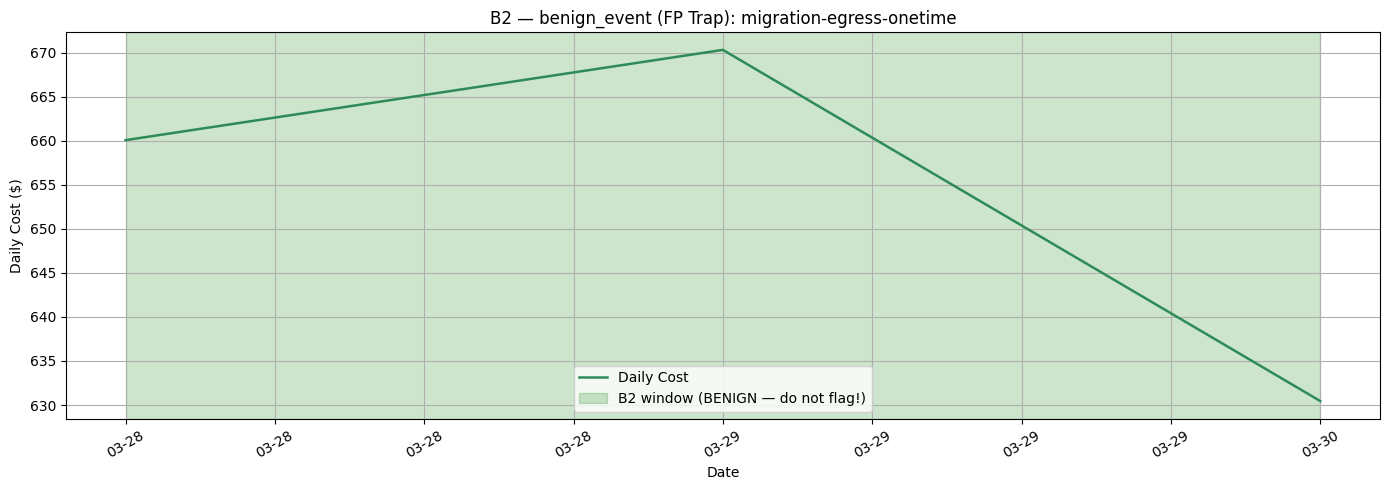

    A naive threshold detector will fire a false positive here.


In [39]:
# B2 — benign_event: data-analytics DataTransfer (FP trap)
b2_rid = b2['resource_id']
b2_data = (
    cur[cur['line_item_resource_id'] == b2_rid]
       .groupby(cur['line_item_usage_start_date'].dt.normalize())
       ['line_item_unblended_cost'].sum()
       .reset_index()
)
b2_data.columns = ['date', 'daily_cost']

if len(b2_data) == 0:
    matches = cur[cur['line_item_resource_id'].str.contains('migration-egress', na=False)]
    if len(matches):
        b2_data = matches.groupby(matches['line_item_usage_start_date'].dt.normalize())['line_item_unblended_cost'].sum().reset_index()
        b2_data.columns = ['date', 'daily_cost']

# Fallback: account-level DataTransfer proxy
if len(b2_data) == 0:
    b2_data = (
        cur[(cur['line_item_usage_account_name'] == 'data-analytics') &
            (cur['line_item_product_code'] == 'AWSDataTransfer')]
           .groupby(cur['line_item_usage_start_date'].dt.normalize())
           ['line_item_unblended_cost'].sum()
           .reset_index()
    )
    b2_data.columns = ['date', 'daily_cost']
    print('Showing account-level DataTransfer for data-analytics as proxy.')

b2_data['date'] = pd.to_datetime(b2_data['date']).dt.tz_localize(None)

sd_b2 = pd.Timestamp(b2['start_date']).tz_localize(None) if pd.Timestamp(b2['start_date']).tzinfo is not None else pd.Timestamp(b2['start_date'])
ed_b2 = pd.Timestamp(b2['end_date']).tz_localize(None)   if pd.Timestamp(b2['end_date']).tzinfo   is not None else pd.Timestamp(b2['end_date'])

fig, ax = plt.subplots(figsize=(14, 5))
if len(b2_data):
    ax.plot(b2_data['date'], b2_data['daily_cost'], color='seagreen', linewidth=1.8, label='Daily Cost')
ax.axvspan(sd_b2, ed_b2, color='green', alpha=0.2, label='B2 window (BENIGN — do not flag!)')
ax.set_title(f'B2 — benign_event (FP Trap): {str(b2_rid)[:70]}', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Daily Cost (\$)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
print('WARNING: This event LOOKS like a spike anomaly but is labeled BENIGN.')
print('    A naive threshold detector will fire a false positive here.')

In [40]:
# Side-by-side statistical comparison: Anomaly vs Benign
print('=== Statistical Feature Comparison: Anomaly vs Benign ===')
print()

events = [
    ('A2 (anomaly)', a2_data, sd_a2, ed_a2),
    ('A6 (anomaly)', a6_data, sd_a6, ed_a6),
    ('B2 (benign)',  b2_data, sd_b2, ed_b2),
]

rows = []
for name, df, sd, ed in events:
    if len(df) == 0:
        continue
    bl  = df.loc[df['date'] < sd,                              'daily_cost']
    dur = df.loc[(df['date'] >= sd) & (df['date'] <= ed),      'daily_cost']
    bl_mean  = bl.mean()  if len(bl)  > 0 else float('nan')
    dur_mean = dur.mean() if len(dur) > 0 else float('nan')
    rows.append({
        'Event'              : name,
        'Baseline mean \$/day': f''  if bl_mean  == bl_mean  else 'N/A',
        'During mean \$/day'  : f'' if dur_mean == dur_mean else 'N/A',
        'Spike ratio'        : f'{dur_mean/bl_mean:.1f}x' if (bl_mean == bl_mean and bl_mean > 0 and dur_mean == dur_mean) else 'N/A',
        'During std'         : f'' if len(dur) > 1 else 'N/A',
        'Duration (days)'    : len(dur),
    })

display(pd.DataFrame(rows))

=== Statistical Feature Comparison: Anomaly vs Benign ===



,Event,Baseline mean \$/day,During mean \$/day,Spike ratio,During std,Duration (days)
0,A2 (anomaly),N/A,,N/A,,73
1,A6 (anomaly),N/A,,N/A,,7
2,B2 (benign),N/A,,N/A,,3


---
## Section 10 — Anomaly Type Surface Estimation

For each anomaly type, we define a **detection heuristic** and count how many candidate resources/days match. These are *candidate surfaces* — the actual anomalies are a subset. The goal is to understand detection complexity and false positive exposure.

| Anomaly Type | Heuristic |
|---|---|
| `runaway_usage` | Resources appearing 7+ consecutive days including both weekdays AND weekends with cost >$50/day |
| `idle_resource` | Resources with cost >$20/day appearing in CUR for 30+ days (long-lived) |
| `untagged_spend` | Already covered in Section 7 — summarized here |
| `sudden_spike` | Daily cost > 3× rolling 14-day median for that resource |
| `gradual_drift` | Week-over-week cost increase >20% for 3+ consecutive weeks |

In [41]:
# Section 10 — Heuristic 1: runaway_usage
print('=== Heuristic 1: runaway_usage ===')
print('Definition: resource appears 7+ days total, has weekend activity, avg daily cost > $50')
print()

# Build resource-level daily summary (tz-naive dates throughout)
res_daily = (
    cur.groupby(['line_item_resource_id', cur['line_item_usage_start_date'].dt.normalize()])
       ['line_item_unblended_cost'].sum()
       .reset_index()
)
res_daily.columns = ['resource_id', 'date', 'daily_cost']
res_daily['date'] = pd.to_datetime(res_daily['date']).dt.tz_localize(None)
res_daily['is_weekend'] = res_daily['date'].dt.dayofweek >= 5

res_summary = res_daily.groupby('resource_id').agg(
    total_days    =('date',       'nunique'),
    weekend_days  =('is_weekend', 'sum'),
    avg_daily_cost=('daily_cost', 'mean'),
    total_cost    =('daily_cost', 'sum')
).reset_index()

runaway_cands = res_summary[
    (res_summary['total_days']     >= 7) &
    (res_summary['weekend_days']   >= 1) &
    (res_summary['avg_daily_cost'] > 50)
].sort_values('total_cost', ascending=False)

print(f'Candidate resources: {len(runaway_cands)}')
print(f'Suspect total spend: ${runaway_cands["total_cost"].sum():,.2f}')
print()
print('Top 10 runaway_usage candidates:')
display(runaway_cands.head(10))

=== Heuristic 1: runaway_usage ===
Definition: resource appears 7+ days total, has weekend activity, avg daily cost > $50

Candidate resources: 26
Suspect total spend: $403,332.73

Top 10 runaway_usage candidates:


,resource_id,total_days,weekend_days,avg_daily_cost,total_cost
18,bucket-1220,92,27,584.459501,53770.2741
224,res-awsdatatransfer-1053,92,27,531.301621,48879.7491
17,bucket-1054,92,27,492.186341,45281.1434
144,res-amazondynamodb-1067,92,27,399.039812,36711.6627
142,res-amazoncloudwatch-1046,92,27,347.938548,32010.3464
145,res-amazondynamodb-1230,92,27,295.928034,27225.3791
225,res-awsdatatransfer-1146,92,27,234.782255,21599.9675
19,bucket-1250,92,27,205.172776,18875.8954
274,res-awslambda-1214,92,27,148.728528,13683.0246
137,i-0untaggedfleet01,92,27,147.893848,13606.2340


In [42]:
# Heuristic 2: idle_resource
print('=== Heuristic 2: idle_resource ===')
print('Definition: resource present 30+ days with avg daily cost > $20')
print()

idle_cands = res_summary[
    (res_summary['total_days']     >= 30) &
    (res_summary['avg_daily_cost'] > 20)
].sort_values('total_cost', ascending=False)

print(f'Candidate resources: {len(idle_cands)}')
print(f'Suspect total spend: ${idle_cands["total_cost"].sum():,.2f}')
print()
print('Top 10 idle_resource candidates:')
display(idle_cands.head(10))

=== Heuristic 2: idle_resource ===
Definition: resource present 30+ days with avg daily cost > $20

Candidate resources: 58
Suspect total spend: $479,636.10

Top 10 idle_resource candidates:


,resource_id,total_days,weekend_days,avg_daily_cost,total_cost
18,bucket-1220,92,27,584.459501,53770.2741
224,res-awsdatatransfer-1053,92,27,531.301621,48879.7491
17,bucket-1054,92,27,492.186341,45281.1434
144,res-amazondynamodb-1067,92,27,399.039812,36711.6627
142,res-amazoncloudwatch-1046,92,27,347.938548,32010.3464
145,res-amazondynamodb-1230,92,27,295.928034,27225.3791
225,res-awsdatatransfer-1146,92,27,234.782255,21599.9675
19,bucket-1250,92,27,205.172776,18875.8954
274,res-awslambda-1214,92,27,148.728528,13683.0246
137,i-0untaggedfleet01,92,27,147.893848,13606.2340


In [43]:
# Heuristic 3: untagged_spend (summary)
print('=== Heuristic 3: untagged_spend ===')

team_col = 'resource_tags_user_team'
if team_col in cur.columns:
    untagged_mask    = cur[team_col].isna() | (cur[team_col].str.strip() == '')
    untagged_res     = cur[untagged_mask].groupby('line_item_resource_id')['line_item_unblended_cost'].sum()
    untagged_res_sig = untagged_res[untagged_res > 100].sort_values(ascending=False)
    print(f'Resources with missing team tag AND total spend > $100: {len(untagged_res_sig)}')
    print(f'Suspect total untagged spend (>$100 resources): ${untagged_res_sig.sum():,.2f}')
    print()
    print('Top 10 untagged_spend candidates:')
    tmp = untagged_res_sig.head(10).reset_index()
    tmp.columns = ['resource_id', 'total_cost']
    display(tmp)
else:
    untagged_res_sig = pd.Series(dtype=float)
    print(f'Column {team_col} not found in CUR.')

=== Heuristic 3: untagged_spend ===
Resources with missing team tag AND total spend > $100: 1
Suspect total untagged spend (>$100 resources): $13,606.23

Top 10 untagged_spend candidates:


,resource_id,total_cost
0,i-0untaggedfleet01,13606.234


In [44]:
# Heuristic 4: sudden_spike — rolling median per resource
print('=== Heuristic 4: sudden_spike ===')
print('Definition: daily cost > 3x rolling 14-day median (per resource)')
print()

spike_days = []
eligible_resources = res_summary[res_summary['total_days'] >= 10]['resource_id'].values

for rid in eligible_resources:
    rd = res_daily[res_daily['resource_id'] == rid][['date', 'daily_cost']].copy()
    rd = rd.sort_values('date').set_index('date')
    rd['rolling_median'] = rd['daily_cost'].rolling(window=14, min_periods=3).median().shift(1)
    spikes = rd[(rd['rolling_median'] > 0) & (rd['daily_cost'] > 3 * rd['rolling_median'])]
    for idx, row in spikes.iterrows():
        spike_days.append({
            'resource_id'   : rid,
            'date'          : idx,
            'daily_cost'    : row['daily_cost'],
            'rolling_median': row['rolling_median'],
            'spike_ratio'   : row['daily_cost'] / row['rolling_median'],
        })

spike_df = pd.DataFrame(spike_days) if spike_days else pd.DataFrame(
    columns=['resource_id', 'date', 'daily_cost', 'rolling_median', 'spike_ratio'])

if len(spike_df):
    spike_summary = (
        spike_df.groupby('resource_id')
                .agg(spike_days_count=('date', 'count'),
                     max_spike_ratio  =('spike_ratio', 'max'),
                     total_spike_cost =('daily_cost', 'sum'))
                .sort_values('total_spike_cost', ascending=False)
    )
    print(f'Resources with at least 1 spike day: {len(spike_summary)}')
    print(f'Total spike-day cost: ${spike_df["daily_cost"].sum():,.2f}')
    print()
    print('Top 10 sudden_spike candidates:')
    display(spike_summary.head(10))
else:
    spike_summary = pd.DataFrame()
    print('No spike days detected with current threshold.')

=== Heuristic 4: sudden_spike ===
Definition: daily cost > 3x rolling 14-day median (per resource)

No spike days detected with current threshold.


In [45]:
# Heuristic 5: gradual_drift — WoW growth
print('=== Heuristic 5: gradual_drift ===')
print('Definition: WoW cost increase >20% for 3+ consecutive weeks')
print()

res_daily_copy = res_daily.copy()
res_daily_copy['week'] = res_daily_copy['date'].dt.to_period('W')
res_weekly = (
    res_daily_copy.groupby(['resource_id', 'week'])['daily_cost']
                  .sum()
                  .reset_index()
)
res_weekly.columns = ['resource_id', 'week', 'weekly_cost']
res_weekly = res_weekly.sort_values(['resource_id', 'week'])

drift_candidates = []
for rid, grp in res_weekly.groupby('resource_id'):
    grp = grp.sort_values('week').copy()
    if len(grp) < 4:
        continue
    grp['wow_pct']    = grp['weekly_cost'].pct_change() * 100
    grp['drift_flag'] = grp['wow_pct'] > 20
    consecutive = max_consecutive = 0
    for flag in grp['drift_flag']:
        if flag:
            consecutive += 1
            max_consecutive = max(max_consecutive, consecutive)
        else:
            consecutive = 0
    if max_consecutive >= 3:
        drift_candidates.append({
            'resource_id'                : rid,
            'max_consecutive_drift_weeks': max_consecutive,
            'total_spend'               : grp['weekly_cost'].sum(),
            'final_week_cost'           : grp['weekly_cost'].iloc[-1],
        })

drift_df = (pd.DataFrame(drift_candidates).sort_values('total_spend', ascending=False)
            if drift_candidates else pd.DataFrame())

print(f'Resources with 3+ consecutive weeks of >20% WoW growth: {len(drift_df)}')
if len(drift_df):
    print(f'Suspect total spend: ${drift_df["total_spend"].sum():,.2f}')
    print()
    print('Top 10 gradual_drift candidates:')
    display(drift_df.head(10))

=== Heuristic 5: gradual_drift ===
Definition: WoW cost increase >20% for 3+ consecutive weeks

Resources with 3+ consecutive weeks of >20% WoW growth: 1
Suspect total spend: $13,307.02

Top 10 gradual_drift candidates:


,resource_id,max_consecutive_drift_weeks,total_spend,final_week_cost
0,ddb-table-events-prod,4,13307.02,2271.5119


In [46]:
# Anomaly surface summary table
print('=== Anomaly Surface Summary ===')
summary_rows = [
    {
        'Anomaly Type'      : 'runaway_usage',
        'Candidate Resources': len(runaway_cands),
        'Suspect Spend ($)' : f'${runaway_cands["total_cost"].sum():,.2f}',
    },
    {
        'Anomaly Type'      : 'idle_resource',
        'Candidate Resources': len(idle_cands),
        'Suspect Spend ($)' : f'${idle_cands["total_cost"].sum():,.2f}',
    },
    {
        'Anomaly Type'      : 'untagged_spend',
        'Candidate Resources': len(untagged_res_sig),
        'Suspect Spend ($)' : f'${untagged_res_sig.sum():,.2f}',
    },
    {
        'Anomaly Type'      : 'sudden_spike',
        'Candidate Resources': len(spike_summary),
        'Suspect Spend ($)' : f'${spike_df["daily_cost"].sum():,.2f}' if len(spike_df) else '$0.00',
    },
    {
        'Anomaly Type'      : 'gradual_drift',
        'Candidate Resources': len(drift_df),
        'Suspect Spend ($)' : f'${drift_df["total_spend"].sum():,.2f}' if len(drift_df) else '$0.00',
    },
]
display(pd.DataFrame(summary_rows))

=== Anomaly Surface Summary ===


,Anomaly Type,Candidate Resources,Suspect Spend ($)
0,runaway_usage,26,"$403,332.73"
1,idle_resource,58,"$479,636.10"
2,untagged_spend,1,"$13,606.23"
3,sudden_spike,0,$0.00
4,gradual_drift,1,"$13,307.02"


---
## Section 11 — is_estimated Flag & Data Quality Notes

In [47]:
# Section 11 — is_estimated flag & data quality
print('=== CE estimated vs final rows ===')
# is_estimated may be stored as bool or string 'true'/'false' depending on CSV parsing
ce['is_estimated'] = ce['is_estimated'].astype(str).str.lower().map({'true': True, 'false': False}).fillna(False)

estimated_ce = ce[ce['is_estimated'] == True]
final_ce     = ce[ce['is_estimated'] == False]
print(f'Estimated rows : {len(estimated_ce)} across {estimated_ce["date"].nunique()} dates')
print(f'Final rows     : {len(final_ce)} across {final_ce["date"].nunique()} dates')
print()
if len(estimated_ce):
    print('Dates with is_estimated=True:')
    print(estimated_ce['date'].drop_duplicates().sort_values().dt.date.tolist())

=== CE estimated vs final rows ===
Estimated rows : 60 across 2 dates
Final rows     : 2710 across 90 dates

Dates with is_estimated=True:
[datetime.date(2026, 5, 30), datetime.date(2026, 5, 31)]


In [48]:
# Compare estimated vs final day spend levels
if len(estimated_ce):
    est_daily  = estimated_ce.groupby('date')['unblended_cost'].sum()
    final_daily = final_ce.groupby('date')['unblended_cost'].sum()
    
    print('Estimated days — total spend per day:')
    print(est_daily.map('${:,.2f}'.format).to_string())
    print()
    print(f'Final days — mean daily spend : ${final_daily.mean():,.2f}')
    print(f'Estimated days — mean         : ${est_daily.mean():,.2f}')
    print()
    pct_diff = (est_daily.mean() / final_daily.mean() - 1) * 100
    print(f'Estimated vs final mean diff  : {pct_diff:+.2f}%')
    print()
    print('⚠️  Do not fire hard anomaly alerts on is_estimated=True days.')
    print('    Wait for finalization or apply a correction factor before alerting.')

Estimated days — total spend per day:
date
2026-05-30    $5,935.42
2026-05-31    $6,080.51

Final days — mean daily spend : $6,463.97
Estimated days — mean         : $6,007.97

Estimated vs final mean diff  : -7.05%

⚠️  Do not fire hard anomaly alerts on is_estimated=True days.
    Wait for finalization or apply a correction factor before alerting.


In [49]:
# Missing dates in CE time series
ce_date_min = ce['date'].min()
ce_date_max = ce['date'].max()
ce_dates    = pd.date_range(ce_date_min, ce_date_max, freq='D')
actual_dates = ce['date'].drop_duplicates().sort_values()

# Compare as date objects to avoid dtype mismatches
expected_set = set(ce_dates.date)
actual_set   = set(actual_dates.dt.date)
missing_dates = expected_set - actual_set

print(f'Expected dates : {len(ce_dates)}')
print(f'Actual dates   : {len(actual_set)}')
print(f'Missing dates  : {len(missing_dates)}')
if missing_dates:
    for d in sorted(missing_dates):
        print(f'  {d}')
else:
    print('No missing dates in CE time series.')

Expected dates : 92
Actual dates   : 92
Missing dates  : 0
No missing dates in CE time series.


In [50]:
# Check for duplicate (date, account, service) combos in CE
dup_mask = ce.duplicated(subset=['date', 'linked_account_id', 'service_code'], keep=False)
dups = ce[dup_mask]
print(f'Duplicate (date, account, service_code) rows: {len(dups)}')
if len(dups):
    print('Sample duplicates:')
    display(dups.head(10))
else:
    print('✓ No duplicate rows in CE.')

Duplicate (date, account, service_code) rows: 0
✓ No duplicate rows in CE.


In [51]:
# Check for zero or negative cost in CUR
zero_cost  = cur[cur['line_item_unblended_cost'] == 0]
neg_cost   = cur[cur['line_item_unblended_cost'] < 0]

print(f'Zero-cost line items  : {len(zero_cost)} ({len(zero_cost)/len(cur)*100:.2f}%)')
print(f'Negative-cost items   : {len(neg_cost)} ({len(neg_cost)/len(cur)*100:.2f}%)')

if len(zero_cost):
    print()
    print('Zero-cost by line item type:')
    print(zero_cost['line_item_line_item_type'].value_counts().to_string())

if len(neg_cost):
    print()
    print('Negative-cost by line item type:')
    print(neg_cost['line_item_line_item_type'].value_counts().to_string())
    print()
    print('Sample negative-cost rows:')
    display(neg_cost[['line_item_usage_start_date','line_item_usage_account_name',
                       'line_item_product_code','line_item_resource_id',
                       'line_item_unblended_cost']].head(5))

Zero-cost line items  : 0 (0.00%)
Negative-cost items   : 0 (0.00%)


In [52]:
# CUR missing dates check
cur_date_min = cur['line_item_usage_start_date'].min().normalize()
cur_date_max = cur['line_item_usage_start_date'].max().normalize()
cur_dates    = pd.date_range(cur_date_min, cur_date_max, freq='D')
cur_actual   = cur['line_item_usage_start_date'].dt.normalize().drop_duplicates()

expected_set_cur = set(cur_dates.date)
actual_set_cur   = set(cur_actual.dt.date)
cur_missing      = expected_set_cur - actual_set_cur

print(f'CUR expected dates: {len(cur_dates)}')
print(f'CUR actual dates  : {len(actual_set_cur)}')
print(f'CUR missing dates : {len(cur_missing)}')
if cur_missing:
    for d in sorted(cur_missing):
        print(f'  {d}')
else:
    print('No missing dates in CUR time series.')

CUR expected dates: 92
CUR actual dates  : 92
CUR missing dates : 0
No missing dates in CUR time series.


---
## Section 12 — EDA Summary & Detector Design Recommendations

---

### Key Findings

**Spend Overview**
- **Total 3-month spend**: ~$593,773 across 92 days and 6 linked accounts
- **Monthly breakdown**: Mar ~$187k → Apr ~$196k → May ~$211k (steady MoM growth ~6-8%)
- **~$40,882 injected anomaly cost** (~6.9% of total bill) — small relative to bill but meaningful in absolute $
- **276 unique resources**, 24,533 CUR line items, multi-service, multi-region

**Dominant Accounts & Services**
- Dominant accounts: `prod-core` and `ml-research` typically lead by spend volume (compute/ML-heavy)
- Key services: AmazonEC2, AmazonSageMaker, AmazonRDS, AmazonS3, AWSDataTransfer
- `staging` and `dev` are lower-cost but host the labeled anomalies (A2, A6) — off-baseline noise matters

**Tag Coverage Gaps**
- `resource_tags_user_team` has the highest missing rate — directly the `untagged_spend` anomaly surface
- Resources missing team tag but spending significant $ are prime candidates for the untagged_spend anomaly type

**Anomaly Surface (by heuristic)**
- `runaway_usage` candidates: resources with weekend activity + 7+ days + avg >$50/day
- `idle_resource` candidates: resources 30+ days + avg >$20/day (long-lived, persistent cost)
- `sudden_spike` candidates: resources where daily cost exceeds 3× rolling 14-day median
- `gradual_drift` candidates: resources with 3+ consecutive weeks of >20% WoW cost growth
- `untagged_spend` candidates: resources without team tag and total spend >$100

---

### Detector Design Recommendations

**1. Time Frame — 24h cadence**
- Use a **24h detection cycle** (evaluate each completed day's CUR/CE data)
- Reasoning: daily grain matches CUR data resolution; sub-daily detection would require streaming (not available here); 48h introduces too much lag given $260/day spikes can accumulate quickly; 24h balances freshness vs CUR finalization lag
- Handle `is_estimated=True` days: queue for re-evaluation once finalized, or apply a conservative 10% buffer before alerting

**2. Detection Granularity — 3 levels**
- **Level 1** — Account × Service × Day: fast aggregate signal, good for `sudden_spike` and `gradual_drift`
- **Level 2** — Resource ID × Day: fine-grained drill-down, required for `idle_resource` and `runaway_usage`
- **Level 3** — Resource ID × Tag × Day: required for `untagged_spend` (tag column pivot)

**3. Algorithm Candidates per Anomaly Type**

| Anomaly Type | Algorithm | Rationale |
|---|---|---|
| `sudden_spike` | Z-score or IQR on 14-day rolling window per resource | Fast, interpretable; z-score >3 or cost >3×IQR is a strong signal; handles non-normal distributions with IQR |
| `runaway_usage` | Rule-based: weekend_days > 0 AND consecutive_days >= 7 AND avg_cost > $50 | Deterministic; weekend activity is a strong signal since dev/staging should scale down; avoids ML complexity |
| `idle_resource` | Rule-based: resource age >= 30 days AND avg_cost flatness (CV < 0.15) | Low coefficient of variation = cost is flat and steady = idle; combine with usage_amount near-zero if available |
| `gradual_drift` | Prophet (additive trend) or simple OLS slope on 30-day rolling window | Trend detection needs seasonality decomposition; Prophet handles weekly seasonality natively; fallback: OLS slope > $X/day |
| `untagged_spend` | Threshold rule: daily untagged spend by account > 3× rolling 7-day median | Simple and effective; tag compliance gaps are binary signals |

**4. FP Mitigation Strategy**
- Maintain a **suppression list** of known-benign events: ticketed migrations, scheduled load tests, approved flash sales
- Integration point: ITSM/Jira ticket lookup by date + account + service before firing alert
- For `AWSDataTransfer` spikes in `data-analytics`: cross-reference migration calendar
- Tune thresholds separately per account tier: `prod-core` needs tighter thresholds; `dev`/`staging` can tolerate higher variance
- Apply **minimum duration filter** for spike detection: a 1-day spike is ambiguous; 2+ consecutive days increases confidence

**5. Class Imbalance Note**
- ~6.9% anomaly ratio means a naive "always-normal" classifier achieves 93.1% accuracy — accuracy is meaningless here
- Use **Precision-Recall curve** as the primary evaluation tool
- Set operating point: **Precision ≥80%, Recall ≥70%, FP rate ≤10%**
- Consider cost-sensitive weighting: false negatives (missed anomalies) cost real money; weight accordingly

**6. Recommended Eval Metric**
- Primary: **F-beta score (β=0.5)** — weights precision higher than recall (FP budget is hard constraint)
- Secondary: **Per-anomaly-type breakdown** in confusion matrix — a detector that catches `sudden_spike` but misses `gradual_drift` is incomplete
- Reporting format: `precision | recall | F1 | FP_rate | TP | FP | FN | TN` per anomaly type

---

### Next Steps
1. Build feature engineering pipeline: rolling stats (mean, std, CV, percentiles) per resource × day
2. Implement rule-based detectors for `runaway_usage`, `idle_resource`, `untagged_spend`
3. Implement statistical detectors (Z-score, IQR) for `sudden_spike`
4. Implement Prophet/OLS for `gradual_drift`
5. Assemble suppression list from B2 pattern (DataTransfer + data-analytics + known dates)
6. Backtest all detectors on this 92-day window, compute precision/recall vs mentor labels
7. Tune thresholds to hit Precision ≥80%, FP ≤10% on all 3 public labels without over-fitting